# GNN Powerflow V2.6 — Data Generation

Generates and saves training network datasets as JSON files in `TRAINING_NETWORKS_DIR`.

**Output**: dataset JSONs consumed by `GNN_Powerflow_V2.6_Training.ipynb`

In [77]:
# %%
import copy
import logging
import os
import pickle
import random
import time
from typing import Dict, List, Optional, Tuple
import json
from datetime import datetime
from dataclasses import dataclass, field, asdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pypsa
import pypowsybl as pp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch_geometric.data import Batch, Data, Dataset
from torch_geometric.nn import GATv2Conv, GCNConv, GraphConv
from tqdm import tqdm

import urllib

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Suppress verbose output from PyPSA and dependencies during data generation
for _log in ("pypsa", "pypsa.pf", "pypsa.components", "numexpr", "linopy"):
    logging.getLogger(_log).setLevel(logging.WARNING)
logging.getLogger("numexpr").setLevel(logging.ERROR)
logging.getLogger("linopy").setLevel(logging.ERROR)

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)


In [78]:
# ── Configurable paths ───────────────────────────────────────────────────────
# Set DATA_ROOT to wherever your data folders live.
# Use "." to keep everything relative to the repo (default).
# Example: DATA_ROOT = r"C:\Users\you\OneDrive\Data_PF_GNN"
import os as _os
DATA_ROOT             = r"C:\Users\STSI\OneDrive - USN\Data_PF_GNN"                                             # ← change this
GRID_MODEL_FILES      = _os.path.join(DATA_ROOT, "grid_model_files")    # static grid CSV/RAW files
TRAINING_NETWORKS_DIR = _os.path.join(DATA_ROOT, "training_networks_saved")  # dataset JSONs
TRAINING_RESULTS_DIR  = _os.path.join(DATA_ROOT, "training_results_saved")   # sweep result JSONs/CSVs


In [79]:
#test and execution toggles
run_smoke_test=False # to run a smoke test on network generation
run_regression_test=False # to run a regression test on the GNN training loop (with very limited epochs and data)
run_powsybl_extract = False # extract data from powsybl for the first time, or re-extract after edits to the extraction code
run_cigre_extract = False # extract data from CIGRE for the first time, or re-extract after edits to the extraction code    

In [80]:
import itertools

# ── Style pools ──────────────────────────────────────────────────────────────
_LINE_STYLES  = ["-", "--", "-.", ":"]
_MARKERS      = ["", "o", "s", "^", "D", "v", "P", "X"]
_COLOR_CYCLE  = plt.rcParams["axes.prop_cycle"].by_key()["color"]

## Grid Extraction Utilities
_(PowerSyBl / CIGRE14 extraction — run once to populate `GRID_MODEL_FILES`)_

#### Powsybl grid model conversion to PyPSA-readable format

In [81]:
# download avaliable files from powsybl repo

RAW_BASE = "https://raw.githubusercontent.com/powsybl/powsybl-distribution/main/resources/PSSE"
FILES = {
    "IEEE_30_bus.raw":  "ieee30",
    "IEEE_57_bus.raw":  "ieee57",
    "IEEE_118_bus.raw": "ieee118",
}

for filename, base_name in FILES.items():
    dest = os.path.join(GRID_MODEL_FILES, filename)
    if os.path.exists(dest):
        print(f"  already exists: {dest}")
    else:
        url = f"{RAW_BASE}/{filename}"
        urllib.request.urlretrieve(url, dest)
        print(f"  ✅ downloaded: {dest}")

  already exists: C:\Users\STSI\OneDrive - USN\Data_PF_GNN\grid_model_files\IEEE_30_bus.raw
  already exists: C:\Users\STSI\OneDrive - USN\Data_PF_GNN\grid_model_files\IEEE_57_bus.raw
  already exists: C:\Users\STSI\OneDrive - USN\Data_PF_GNN\grid_model_files\IEEE_118_bus.raw


#### Powsybl grid model conversion to PyPSA-readable format

In [82]:

def load_powsybl_network_from_file(path: str, fmt: str | None = None) -> pp.network.Network:
    """Load a grid file into a powsybl network and run AC power flow."""
    net = pp.network.load(path) if fmt is None else pp.network.load(path, fmt)
    lf_params = pp.loadflow.Parameters(distributed_slack=False)
    pp.loadflow.run_ac(net, lf_params)
    return net


def export_powsybl_to_tables(
    net,
    sbase_mva: float = 100.0,
    save_dir: str = "grid_model_files",
    base_name: str = "ieee39",
) -> tuple:
    buses_df  = net.get_buses(all_attributes=True)
    lines_df  = net.get_lines(all_attributes=True)
    trafos_df = net.get_2_windings_transformers(all_attributes=True)
    gens_df   = net.get_generators(all_attributes=True)
    loads_df  = net.get_loads(all_attributes=True)

    # vnom lookup: voltage_level_id → kV
    vls = net.get_voltage_levels(all_attributes=True)
    vnom_kv = vls["nominal_v"].to_dict()   # {vl_id: kV}

    # Add nominal_v to buses and normalize v_mag to p.u.
    buses_df["nominal_v"] = buses_df["voltage_level_id"].map(vls["nominal_v"]) 
    buses_df["nominal_v"] = buses_df["nominal_v"].fillna(1.0)
    buses_df["v_mag_pu"]  = buses_df["v_mag"] / buses_df["nominal_v"]
    buses_df["v_ang_deg"] = buses_df["v_angle"]

    def zbase(vl_id: str) -> float:
        vnom = vnom_kv.get(vl_id, 1.0)
        if vnom <= 0:
            vnom = 1.0
        return (vnom ** 2) / sbase_mva     # Ω — divide Z[Ω] by this → p.u.

    # ── Lines ────────────────────────────────────────────────────────────────
    for idx, row in lines_df.iterrows():
        zb = zbase(row.get("voltage_level1_id", ""))
        for col in ["r", "x"]:
            if col in lines_df.columns:
                lines_df.loc[idx, col] = row[col] / zb
        vnom1 = vnom_kv.get(row.get("voltage_level1_id", ""), 1.0) or 1.0
        vnom2 = vnom_kv.get(row.get("voltage_level2_id", ""), 1.0) or 1.0
        if max(vnom1, vnom2) / max(min(vnom1, vnom2), 0.1) > 1.5:
            # Cross-voltage-level: powsybl transformer branch artifact — zero out shunt terms
            for col in ["b1", "b2", "g1", "g2"]:
                if col in lines_df.columns:
                    lines_df.loc[idx, col] = 0.0
        else:
            for col in ["b1", "b2", "g1", "g2"]:
                if col in lines_df.columns:
                    lines_df.loc[idx, col] = row[col] * zb

    # ── Transformers ─────────────────────────────────────────────────────────
    for idx, row in trafos_df.iterrows():
        zb = zbase(row.get("voltage_level1_id", ""))
        for col in ["r", "x", "r_at_current_tap", "x_at_current_tap"]:
            if col in trafos_df.columns:
                trafos_df.loc[idx, col] = row[col] / zb
        for col in ["b", "g", "g_at_current_tap", "b_at_current_tap"]:
            if col in trafos_df.columns:
                trafos_df.loc[idx, col] = row[col] * zb

    # ── Generators: MW → p.u. ─────────────────────────────────────────────
    for col in ["target_p", "min_p", "max_p", "target_q", "min_q", "max_q", "p", "q"]:
        if col in gens_df.columns:
            gens_df[col] = gens_df[col] / sbase_mva

    # ── Loads: MW → p.u. ──────────────────────────────────────────────────
    for col in ["p0", "q0", "p", "q"]:
        if col in loads_df.columns:
            loads_df[col] = loads_df[col] / sbase_mva

    os.makedirs(save_dir, exist_ok=True)
    buses_df.to_csv( f"{save_dir}/{base_name}_buses.csv")
    lines_df.to_csv( f"{save_dir}/{base_name}_lines.csv")
    trafos_df.to_csv(f"{save_dir}/{base_name}_transformers.csv")
    gens_df.to_csv(  f"{save_dir}/{base_name}_gens.csv")
    loads_df.to_csv( f"{save_dir}/{base_name}_loads.csv")
    
    # ── Shunt compensators: b in Siemens → p.u. ──────────────────────────
    shunts_df = net.get_shunt_compensators(all_attributes=True)
    if len(shunts_df) > 0:
        for idx, row in shunts_df.iterrows():
            zb = zbase(row.get("voltage_level_id", ""))
            shunts_df.loc[idx, "b"] = row["b"] * zb
        shunts_df.to_csv(f"{save_dir}/{base_name}_shunts.csv")
        
    logger.info(
        f"{base_name}: exported {len(buses_df)} buses, {len(lines_df)} lines, "
        f"{len(trafos_df)} trafos, {len(gens_df)} gens, {len(loads_df)} loads"
    )
    return buses_df, lines_df, trafos_df, gens_df, loads_df


In [83]:
# One-off extraction: only re-run when updating the source grid file

if run_powsybl_extract:     
    n_powsybl = load_powsybl_network_from_file(r"grid_model_files/IEEE 39 bus.RAW")
    buses_df, lines_df, trafos_df, gens_df, loads_df = export_powsybl_to_tables(n_powsybl)
    # Spot-check scaled values
    print(f"T-2-30 x (should be ~0.0181): {trafos_df['x'].iloc[0]:.4f}")
    print(f"L-1-2 x  (should be ~0.0411): {lines_df['x'].iloc[0]:.4f}")
    print(f"L-1-2 b1 (should be ~0.3494): {lines_df['b1'].iloc[0]:.4f}")
    print(f"Total load (should be ~61.5 p.u.): {loads_df['p0'].sum():.2f}")
else:
    print("Powsybl extract skipped. Set run_powsybl_extract=True to re-export.")

Powsybl extract skipped. Set run_powsybl_extract=True to re-export.


In [84]:


IEEE_SYSTEMS = {
    "ieee30":  "IEEE_30_bus.raw",
    "ieee57":  "IEEE_57_bus.raw",
    "ieee118": "IEEE_118_bus.raw",
}

if run_powsybl_extract:
    for base_name, raw_file in IEEE_SYSTEMS.items():
        net = load_powsybl_network_from_file(os.path.join(GRID_MODEL_FILES, raw_file))
        buses_df, lines_df, trafos_df, gens_df, loads_df=export_powsybl_to_tables(net, sbase_mva=100.0,
                                 save_dir=GRID_MODEL_FILES,
                                 base_name=base_name)
        print(f"T-2-30 x (should be ~0.0xxx): {trafos_df['x'].iloc[0]:.4f}")
        print(f"L-1-2 x  (should be ~0.0xxx): {lines_df['x'].iloc[0]:.4f}")
        print(f"L-1-2 b1 (should be ~0.xxx): {lines_df['b1'].iloc[0]:.4f}")
        print(f"Total load (should be ~0xx.x p.u.): {loads_df['p0'].sum():.2f}")

else:
    print("Powsybl extract skipped. Set run_powsybl_extract=True to re-export.")

Powsybl extract skipped. Set run_powsybl_extract=True to re-export.


#### Converting from Pandapower Cigre14 to pypsa

In [85]:
def export_pandapower_cigre_mv(
    sbase_mva: float = 100.0,
    save_dir: str = GRID_MODEL_FILES,
    base_name: str = "cigre14",
    with_der: bool = False,
) -> None:
    """
    Export pandapower CIGRE MV network to 5 CSVs compatible with
    load_system_from_csv / create_csv_based_topology_variant.

    Network: 15 buses (1 HV slack + 14 MV buses), 15 lines, 2 trafos,
             18 loads, no generators (ext_grid as slack).
    All values converted to p.u. on sbase_mva base.
    Voltage base: 20 kV MV, 110 kV HV.
    """
    import pandapower as pandapower
    import pandapower.networks as pn

    net = pn.create_cigre_network_mv(with_der=with_der)  # base case without DER
    pandapower.runpp(net)

    os.makedirs(save_dir, exist_ok=True)

    # ── Buses ────────────────────────────────────────────────────────────────
    bus_rows = []
    for idx, row in net.bus.iterrows():
        vnom_kv  = float(row["vn_kv"])
        vmag_pu  = float(net.res_bus.loc[idx, "vm_pu"])
        vang_deg = float(net.res_bus.loc[idx, "va_degree"])
        bus_rows.append(dict(
            bus_id=f"B{idx}",
            vnom_kv=vnom_kv,
            v_mag_pu=vmag_pu,
            v_ang_deg=vang_deg,
            in_service=row["in_service"],
        ))
    buses_df = pd.DataFrame(bus_rows).set_index("bus_id")

    # ── Lines ────────────────────────────────────────────────────────────────
    line_rows = []
    for idx, row in net.line.iterrows():
        from_bus = row["from_bus"]
        to_bus   = row["to_bus"]
        vnom_kv  = float(net.bus.loc[from_bus, "vn_kv"])
        zbase    = (vnom_kv ** 2) / sbase_mva        # Ω
        length   = float(row["length_km"])

        # pandapower stores per-km values
        r = row["r_ohm_per_km"] * length / zbase
        x = row["x_ohm_per_km"] * length / zbase
        # c_nf_per_km → b = ω·C, ω=2π·50
        c_total_f = row["c_nf_per_km"] * length * 1e-9
        b_total   = 2 * np.pi * 50 * c_total_f * zbase  # p.u.
        snom      = float(row.get("max_i_ka", 0.3)) * vnom_kv * np.sqrt(3) / sbase_mva

        line_rows.append(dict(
            line_id=f"L-{from_bus}-{to_bus}-{idx}",
            bus1_id=f"B{from_bus}",
            bus2_id=f"B{to_bus}",
            r=max(r, 1e-6),
            x=max(x, 1e-4),
            b1=b_total / 2,
            b2=b_total / 2,
            rateds=max(snom, 0.1),
        ))
    lines_df = pd.DataFrame(line_rows).set_index("line_id")

    # ── Transformers ─────────────────────────────────────────────────────────
    trafo_rows = []
    for idx, row in net.trafo.iterrows():
        hv_bus  = row["hv_bus"]
        lv_bus  = row["lv_bus"]
        vnom_hv = float(net.bus.loc[hv_bus, "vn_kv"])
        zbase   = (vnom_hv ** 2) / sbase_mva
        snom_mva= float(row["sn_mva"])
        vkr_pu  = float(row["vkr_percent"]) / 100.0   # resistive part of short-circuit voltage
        vk_pu   = float(row["vk_percent"])  / 100.0   # total short-circuit voltage
        # Convert from trafo MVA base to system base
        r = vkr_pu * (sbase_mva / snom_mva)
        x = np.sqrt(max(vk_pu**2 - vkr_pu**2, 0.0)) * (sbase_mva / snom_mva)

        trafo_rows.append(dict(
            trafo_id=f"T-{hv_bus}-{lv_bus}-{idx}",
            bus1_id=f"B{hv_bus}",
            bus2_id=f"B{lv_bus}",
            r=max(r, 1e-6),
            x=max(x, 1e-4),
            rateds=snom_mva / sbase_mva,
            tap=1.0,
        ))
    trafos_df = pd.DataFrame(trafo_rows).set_index("trafo_id")

    # ── Generators (ext_grid as Slack) ───────────────────────────────────────
    gen_rows = []
    for idx, row in net.ext_grid.iterrows():
        bus = row["bus"]
        gen_rows.append(dict(
            gen_id=f"EG{idx}",
            bus_id=f"B{bus}",
            control="Slack",
            maxp=9999.0 / sbase_mva,
            minp=0.0,
            targetp=0.0,
            targetq=0.0,
            voltage_regulator_on=1,
            v_set=float(row.get("vm_pu", 1.02)),
        ))
    # pandapower gens (if any)
    if len(net.gen) > 0:
        for idx, row in net.gen.iterrows():
            bus = row["bus"]
            pnom = float(row["p_mw"]) / sbase_mva
            gen_rows.append(dict(
                gen_id=f"G{idx}",
                bus_id=f"B{bus}",
                control="PV",
                maxp=pnom,
                minp=0.0,
                targetp=pnom,
                targetq=0.0,
                voltage_regulator_on=1,
                v_set=float(row.get("vm_pu", 1.0)),
            ))
    gens_df = pd.DataFrame(gen_rows).set_index("gen_id")

    # ── Loads ─────────────────────────────────────────────────────────────────
    load_rows = []
    for idx, row in net.load.iterrows():
        bus = row["bus"]
        load_rows.append(dict(
            load_id=f"L{idx}",
            bus_id=f"B{bus}",
            p0=float(row["p_mw"])   / sbase_mva,
            q0=float(row["q_mvar"]) / sbase_mva,
        ))
    loads_df = pd.DataFrame(load_rows).set_index("load_id")

    # ── Save ──────────────────────────────────────────────────────────────────
    buses_df.to_csv( f"{save_dir}/{base_name}_buses.csv")
    lines_df.to_csv( f"{save_dir}/{base_name}_lines.csv")
    trafos_df.to_csv(f"{save_dir}/{base_name}_transformers.csv")
    gens_df.to_csv(  f"{save_dir}/{base_name}_gens.csv")
    loads_df.to_csv( f"{save_dir}/{base_name}_loads.csv")

    print(f"  ✅ {base_name}: {len(buses_df)} buses | {len(lines_df)} lines | "
          f"{len(trafos_df)} trafos | {len(gens_df)} gens | {len(loads_df)} loads")
    print(f"     Total load: {loads_df['p0'].sum()*sbase_mva:.1f} MW  "
          f"({loads_df['p0'].sum():.3f} p.u.)")


In [86]:

if run_cigre_extract:
    export_pandapower_cigre_mv(
        save_dir=GRID_MODEL_FILES,
        base_name="cigre14",
        with_der=False,
    )
    export_pandapower_cigre_mv(
        save_dir=GRID_MODEL_FILES,
        base_name="cigre14der",
        with_der="all",
    )

## Data Generation Functions


In [100]:

def _busname_to_int_safe(bus_name, fallback_map: dict[str, int]) -> int:
    """
    Map bus names to integer IDs in a robust way.

    Supports:
      - 'Bus 3' -> 3
      - 'B30'   -> 30
    For other patterns, assigns a stable ID via fallback_map.
    """
    if isinstance(bus_name, str):
        b = bus_name.strip()
        # Pattern: 'Bus 3'
        if b.lower().startswith("bus"):
            parts = b.split()
            if len(parts) >= 2 and parts[-1].isdigit():
                return int(parts[-1])
        # Pattern: 'B30'
        if b.startswith("B"):
            num_part = b[1:].strip()
            if num_part.isdigit():
                return int(num_part)
    if bus_name not in fallback_map:
        fallback_map[bus_name] = len(fallback_map) + 1
    return fallback_map[bus_name]


def solve_power_flow_with_slack(network, gen_buses, distribute_slack_flag,
                                distributed_slack_mode="proportional",
                                custom_slack_weights=None):
    import networkx as nx

    def _bus_to_int(bus_name, fallback):
        """Parse 'Bus 3' → 3, 'B30' → 30, else assign stable fallback ID."""
        if isinstance(bus_name, str):
            b = bus_name.strip()
            if b.lower().startswith("bus"):
                parts = b.split()
                if len(parts) >= 2 and parts[-1].isdigit():
                    return int(parts[-1])
            if b.startswith("B"):
                num = b[1:].strip()
                if num.isdigit():
                    return int(num)
        if bus_name not in fallback:
            fallback[bus_name] = len(fallback) + 1
        return fallback[bus_name]

    # ── Guard: raise before pf() if network is disconnected ──
    G = nx.Graph()
    for _, line in network.lines.iterrows():
        G.add_edge(line.bus0, line.bus1)
    for _, trafo in network.transformers.iterrows():
        G.add_edge(trafo.bus0, trafo.bus1)
    for bus in network.buses.index:
        G.add_node(bus)

    if not nx.is_connected(G):
        raise RuntimeError(
            f"Network disconnected "
            f"({nx.number_connected_components(G)} components) — skip PF"
        )

    if not distribute_slack_flag:
        network.pf(use_seed=True)
        return

    if not gen_buses:
        fallback = {}
        gen_bus_names = sorted(set(network.generators.bus.values))
        gen_buses = [_bus_to_int(b, fallback) for b in gen_bus_names]

    if not gen_buses:
        network.pf(use_seed=True)
        return

    if "slack_weight" not in network.generators.columns:
        network.generators["slack_weight"] = 0.0

    primary_slack_bus = gen_buses[0]
    fallback = {}
    candidates = []
    for g in network.generators.index:
        bus_name = network.generators.loc[g, "bus"]
        bus_id = _bus_to_int(bus_name, fallback)
        if bus_id == primary_slack_bus:
            continue
        candidates.append((g, bus_id))

    if distributed_slack_mode == "proportional":
        total = 0.0
        for g, _ in candidates:
            w = float(network.generators.loc[g, "p_nom"])
            network.generators.loc[g, "slack_weight"] = w
            total += w
        if total > 0:
            network.generators["slack_weight"] /= total
    elif distributed_slack_mode == "equal":
        if candidates:
            w = 1.0 / len(candidates)
            for g, _ in candidates:
                network.generators.loc[g, "slack_weight"] = w
    elif distributed_slack_mode == "custom":
        if custom_slack_weights is None:
            raise ValueError("custom slack requires custom_slack_weights")
        total = 0.0
        for g, bus_id in candidates:
            if bus_id in custom_slack_weights:
                w = float(custom_slack_weights[bus_id])
                network.generators.loc[g, "slack_weight"] = w
                total += w
        if total > 0:
            network.generators["slack_weight"] /= total
    else:
        raise ValueError(f"Unknown distributed_slack_mode: {distributed_slack_mode}")

    network.pf(use_seed=True, distribute_slack=True)

# pypsa issue handling
def ensure_generators_per_subnetwork(net: pypsa.Network) -> None:
    """
    Ensure every PyPSA subnetwork has at least one generator.

    PyPSA's sub_network_pf_singlebus sets slack_generator=None when a
    subnetwork has no generators, which causes KeyError: None during PF.

    This fix detects such subnetworks via net.buses['sub_network'] grouping
    (after determine_network_topology()) and attaches a tiny dummy Slack
    generator to one bus in each offending subnetwork.

    Known affected subnetworks in IEEE39 (powsybl CSV import):
      - VL11-12-13_1  (bus B12, load-only inside VL11-12-13 voltage level)
      - VL19-20-33-34_1 (bus B20, load-only inside VL19-20-33-34 voltage level)
    """
    net.determine_network_topology()

    for sn_label, bus_group in net.buses.groupby("sub_network"):
        sn_buses = list(bus_group.index)
        sn_gens = net.generators[net.generators["bus"].isin(sn_buses)]

        if len(sn_gens) == 0:
            bus_name = sn_buses[0]
            gen_name = f"DummySlack_{bus_name}"

            if gen_name in net.generators.index:
                continue

            net.add(
                "Generator",
                gen_name,
                bus=bus_name,
                control="Slack",
                p_nom=1e-3,
                p_min_pu=0.0,
                p_set=0.0,
                q_set=0.0,
            )
            logger.warning(
                f"Subnetwork {sn_label} (bus '{bus_name}'): no generators — "
                f"attached dummy Slack generator '{gen_name}'"
            )


def sanity_check_power_flow(
    network: pypsa.Network,
    base_system: str,
    require_connected: bool = True,
    min_loads: int = 1,
    voltage_max_threshold: float = 1.5,
    voltage_min_threshold: float = 0.5,
) -> None:
    """
    Post-PF sanity checks:
    - Connectivity (lines+trafos)
    - Finite, reasonable voltages
    - At least one slack generator
    - No NaNs in PF results
    """
    # 1) Connectivity
    import networkx as nx

    G = nx.Graph()
    for _, line in network.lines.iterrows():
        G.add_edge(line["bus0"], line["bus1"])
    for _, trafo in network.transformers.iterrows():
        G.add_edge(trafo["bus0"], trafo["bus1"])

    if require_connected and len(G.nodes()) > 0 and not nx.is_connected(G):
        raise RuntimeError(f"{base_system}: network is disconnected after PF")

    # 2) Voltage sanity
    if hasattr(network, "buses_t") and hasattr(network.buses_t, "v_mag_pu"):
        v = network.buses_t.v_mag_pu.values.flatten()
        if not np.all(np.isfinite(v)):
            raise RuntimeError(f"{base_system}: non-finite bus voltages after PF")
        if not np.all((v > voltage_min_threshold) & (v < voltage_max_threshold)):
            raise RuntimeError(f"{base_system}: Voltages out of range ({voltage_min_threshold}-{voltage_max_threshold}) after PF")
    else:
        logger.warning(f"{base_system}: buses_t.v_mag_pu not available for sanity check")

    # 3) Slack generator presence
    slack_gens = network.generators.index[network.generators["control"] == "Slack"]
    if len(slack_gens) == 0:
        logger.warning(f"{base_system}: no explicit Slack generator found")

    # 4) Check loads
    if len(network.loads) < min_loads:
        raise RuntimeError(
            f"{base_system}: insufficient loads ({len(network.loads)}) after PF"
        )

    logger.info(
        f"{base_system}: PF sanity OK "
        f"(buses={len(network.buses)}, gens={len(network.generators)}, "
        f"loads={len(network.loads)})"
    )

# pypsa issue handling
def ensure_generators_per_subnetwork(net: pypsa.Network) -> None:
    """
    Ensure every PyPSA subnetwork has at least one generator.

    PyPSA's sub_network_pf_singlebus sets slack_generator=None when a
    subnetwork has no generators, which causes KeyError: None during PF.

    This fix detects such subnetworks via net.buses['sub_network'] grouping
    (after determine_network_topology()) and attaches a tiny dummy Slack
    generator to one bus in each offending subnetwork.

    Known affected subnetworks in IEEE39 (powsybl CSV import):
      - VL11-12-13_1  (bus B12, load-only inside VL11-12-13 voltage level)
      - VL19-20-33-34_1 (bus B20, load-only inside VL19-20-33-34 voltage level)
    """
    net.determine_network_topology()

    for sn_label, bus_group in net.buses.groupby("sub_network"):
        sn_buses = list(bus_group.index)
        sn_gens = net.generators[net.generators["bus"].isin(sn_buses)]

        if len(sn_gens) == 0:
            bus_name = sn_buses[0]
            gen_name = f"DummySlack_{bus_name}"

            if gen_name in net.generators.index:
                continue

            net.add(
                "Generator",
                gen_name,
                bus=bus_name,
                control="Slack",
                p_nom=1e-3,
                p_min_pu=0.0,
                p_set=0.0,
                q_set=0.0,
            )
            logger.warning(
                f"Subnetwork {sn_label} (bus '{bus_name}'): no generators — "
                f"attached dummy Slack generator '{gen_name}'"
            )


def debug_generators_tables(network: pypsa.Network, tag: str = "") -> None:
    logger.debug(f"[{tag}] generators index: {list(network.generators.index)}")

    if hasattr(network, "generators_t"):
        attrs = list(network.generators_t.__dict__.keys())
        logger.debug(f"[{tag}] generators_t attrs: {attrs}")

        for attr in ("p_set", "p", "q"):
            if attr in attrs:
                df = getattr(network.generators_t, attr)
                logger.debug(
                    f"[{tag}] generators_t.{attr} "
                    f"shape={df.shape}, "
                    f"columns={list(df.columns)}"
                )
            else:
                logger.debug(f"[{tag}] generators_t.{attr} is MISSING")
    else:
        logger.debug(f"[{tag}] network has no generators_t")

# 26.03.13 STSI: generic wrapper to create topology variants for different base systems
def create_topology_variant(base_system: str, **kwargs) -> pypsa.Network:
    if base_system == "ieee9":
        return create_9_bus_network_topology_variants(**kwargs)
    elif base_system == "ieee39":
        return create_ieee39_topology_variant(**kwargs)
    elif base_system == "ieee30":          # +++ new
        return create_ieee30_topology_variant(**kwargs)
    elif base_system == "ieee57":          # +++ new
        return create_ieee57_topology_variant(**kwargs)
    elif base_system == "ieee118":
        return create_ieee118_topology_variant(**kwargs)
    elif base_system == "cigre14":
        return create_cigre14_topology_variant(**kwargs)
    elif base_system == "cigre14der":      # +++ new
        return create_cigre14der_topology_variant(**kwargs)
    else:
        raise ValueError(
            f"Unknown base_system '{base_system}'. "
            f"Valid: ieee9, ieee39, ieee30, ieee57, ieee118, cigre14, cigre14der"
        )




In [113]:
def validate_bus_sets(gen_buses: list[int], load_buses: list[int]) -> tuple[list[int], list[int]]:
    assert 1 <= len(gen_buses) <= 3, f"Must have 1–3 generators, got {len(gen_buses)}"
    assert len(set(gen_buses)) == len(gen_buses), "Generator buses must be unique"
    assert all(isinstance(b, int) and b >= 1 for b in gen_buses), "Generator bus indices must be positive integers"

    assert len(load_buses) >= 1, "Must have at least 1 load bus"
    assert all(isinstance(b, int) and b >= 1 for b in load_buses), "Load bus indices must be positive integers"

    original_load_buses = load_buses.copy()
    filtered = []
    skipped = []
    for bus in load_buses:
        if bus in gen_buses:
            skipped.append(bus)
            logger.warning(f"Load bus {bus} conflicts with generator bus. Skipping.")
        elif bus in filtered:
            logger.warning(f"Duplicate load bus {bus} found. Skipping duplicate.")
        else:
            filtered.append(bus)

    assert len(filtered) >= 1, (
        f"After removing conflicts with generator buses {gen_buses}, "
        f"no valid load buses remain from {original_load_buses}"
    )
    if skipped:
        logger.info(f"Skipped load buses due to generator conflicts: {skipped}")
    return gen_buses, filtered

def fill_load_defaults(
    load_buses: list[int],
    load_base_p: dict[int, tuple[float, float]] | None,
    load_base_q: dict[int, tuple[float, float]] | None,
) -> tuple[dict[int, tuple[float, float]], dict[int, tuple[float, float]]]:
    load_base_p = {} if load_base_p is None else dict(load_base_p)
    load_base_q = {} if load_base_q is None else dict(load_base_q)

    default_loads_p = {5: (0.9, 1.25), 7: (0.9, 1.25), 9: (0.9, 1.25)}
    default_loads_q = {5: (0.3, 0.5), 7: (0.3, 0.5), 9: (0.3, 0.5)}

    for bus in load_buses:
        if bus not in load_base_p:
            load_base_p[bus] = default_loads_p.get(bus, (0.5, 1.0))
            logger.info(f"Using default load_base_p for bus {bus}: {load_base_p[bus]}")
        if bus not in load_base_q:
            load_base_q[bus] = default_loads_q.get(bus, (0.2, 0.4))
            logger.info(f"Using default load_base_q for bus {bus}: {load_base_q[bus]}")
    return load_base_p, load_base_q

def default_p_set_generators(gen_buses: list[int], p_set_generators: dict[int, float] | None) -> dict[int, float]:
    if p_set_generators is None:
        p_set_generators = {}
    if p_set_generators:
        return p_set_generators
    non_slack = [b for b in gen_buses if b != gen_buses[0]]
    default_setpoints = [1.63, 0.85]  # for 2nd and 3rd generator
    for i, bus in enumerate(non_slack):
        p_set_generators[bus] = default_setpoints[i] if i < len(default_setpoints) else 0.5
    return p_set_generators

def make_bus_coordinates(max_bus_needed: int) -> dict[int, tuple[float, float]]:
    base_coordinates = {
        1: (0, 0),
        2: (4, 6),
        3: (-4, 6),
        4: (0, 2),
        5: (-2, 4),
        6: (-2, 6),
        7: (0, 6),
        8: (2, 6),
        9: (2, 4),
    }
    bus_coordinates = base_coordinates.copy()
    if max_bus_needed > 9:
        angle_step = 360 / (max_bus_needed - 9)
        radius = 8
        for i in range(10, max_bus_needed + 1):
            angle = np.radians((i - 10) * angle_step)
            x = radius * np.cos(angle) + np.random.uniform(-1, 1)
            y = radius * np.sin(angle) + np.random.uniform(-1, 1)
            bus_coordinates[i] = (x, y)
    return bus_coordinates

def add_buses(network: pypsa.Network, max_bus_needed: int, gen_buses: list[int],
              bus_coordinates: dict[int, tuple[float, float]], vnom: float) -> None:
    for i in range(1, max_bus_needed + 1):
        if i == gen_buses[0]:
            bus_type, v_set = "Slack", 1.04
        elif i in gen_buses[1:]:
            bus_type, v_set = "PV", 1.025
        else:
            bus_type, v_set = "PQ", 1.0
        network.add(
            "Bus", f"Bus {i}",
            x=bus_coordinates[i][0],
            y=bus_coordinates[i][1],
            v_nom=vnom,
            v_mag_pu_set=v_set,
            v_mag_pu_min=0.9,
            v_mag_pu_max=1.1,
            type=bus_type,
        )

def add_loads(
    network: pypsa.Network,
    load_buses: list[int],
    load_base_p: dict[int, tuple[float, float]],
    load_base_q: dict[int, tuple[float, float]],
    load_volatility: float,
    load_bias: float,
    sbase: float,
    steps: int,
    snapshots: pd.DatetimeIndex,
    seed: int | None,
) -> None:
    main_rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()
    load_rngs = main_rng.spawn(len(load_buses))

    for idx, bus in enumerate(load_buses):
        rng = load_rngs[idx]
        base_p = rng.uniform(*load_base_p[bus]) * sbase
        base_q = rng.uniform(*load_base_q[bus]) * sbase

        random_walk = np.cumsum(rng.standard_normal(steps))
        normalized = (random_walk - random_walk.min()) / (random_walk.max() - random_walk.min() + 1e-10)
        variation = load_volatility * (normalized - 0.5 + load_bias) * 2

        p_set = base_p * (1 + variation)
        q_set = base_q * (1 + variation)

        network.add(
            "Load", f"Load {bus}",
            bus=f"Bus {bus}",
            p_set=pd.Series(p_set, index=snapshots),
            q_set=pd.Series(q_set, index=snapshots),
        )

def add_generators(
    network: pypsa.Network,
    gen_buses: list[int],
    p_set_generators: dict[int, float],
    sbase: float,
    steps: int,
    snapshots: pd.DatetimeIndex,
) -> None:
    default_gen_configs = [
        {"p_nom": 5.12 * 0.9 * sbase, "p_min_pu": 10 / (5.12 * 0.9), "control": "Slack"},
        {"p_nom": 2.70 * 0.85 * sbase, "p_min_pu": 10 / (2.70 * 0.85), "control": "PV"},
        {"p_nom": 1.25 * 0.85 * sbase, "p_min_pu": 10 / (1.25 * 0.85), "control": "PV"},
    ]
    for i, bus in enumerate(gen_buses):
        if i < len(default_gen_configs):
            config = default_gen_configs[i].copy()
        else:
            config = {"p_nom": 1.0 * sbase, "p_min_pu": 0.1, "control": "PV"}

        gen_data = {
            "bus": f"Bus {bus}",
            "control": config["control"],
            "p_nom": config["p_nom"],
            "p_min_pu": config["p_min_pu"],
        }
        if config["control"] == "Slack":
            gen_data["p_set"] = pd.Series([0.0] * steps, index=snapshots)
        else:
            p_set_value = p_set_generators.get(bus, 0.5)
            gen_data["p_set"] = pd.Series([p_set_value] * steps, index=snapshots)

        network.add("Generator", f"Gen {i+1}", **gen_data)

def add_ieee9_branches(
    network: pypsa.Network,
    max_bus_needed: int,
    sbase: float,
    line_modifications: dict[str, dict[str, float]] | None = None,
) -> None:
    base_branch_data = [
        [1, 4, 0.0000, 0.0576, 0.0000, 1.50, 1.0],  # Transformer
        [4, 5, 0.0100, 0.0920, 0.1580, 1.00, 1.0],  # Line
        [5, 6, 0.0390, 0.1700, 0.3580, 0.75, 1.0],  # Line
        [3, 6, 0.0000, 0.0586, 0.0000, 1.50, 1.0],  # Transformer
        [6, 7, 0.0119, 0.1008, 0.2090, 1.00, 1.0],  # Line
        [7, 8, 0.0085, 0.0720, 0.1490, 1.00, 1.0],  # Line
        [8, 2, 0.0000, 0.0625, 0.0000, 1.75, 1.0],  # Transformer
        [9, 8, 0.0320, 0.1610, 0.3060, 1.00, 1.0],  # Line
        [9, 4, 0.0100, 0.0850, 0.1760, 1.00, 1.0],  # Line
    ]
    branch_count = 0
    for i, branch in enumerate(base_branch_data):
        f_bus, t_bus, r, x, b, s_nom_pu, tap = branch
        if f_bus > max_bus_needed or t_bus > max_bus_needed:
            continue
        s_nom = s_nom_pu * sbase
        is_transformer = (tap != 1.0) or (r == 0.0 and x > 0.0)
        component_type = "Transformer" if is_transformer else "Line"
        component_name = f"{component_type} {i+1}"
        params = {
            "bus0": f"Bus {f_bus}",
            "bus1": f"Bus {t_bus}",
            "r": r,
            "x": x,
            "b": b / 2,
            "s_nom": s_nom,
        }
        if is_transformer:
            params["tap_ratio"] = tap
        if line_modifications and component_name in line_modifications:
            for param, value in line_modifications[component_name].items():
                if param in params:
                    params[param] = value
                    logger.info(f"Modified {component_name}: {param} = {value}")
        network.add(component_type, component_name, **params)
        branch_count += 1
    logger.info(f"Added {branch_count} base lines/transformers")

def add_additional_lines(
    network: pypsa.Network,
    max_bus_needed: int,
    additional_lines: list[dict],
    sbase: float,
) -> None:
    """
    Add additional lines/transformers for extended topology.

    additional_lines: list of dicts with keys:
        "from", "to", optional "r", "x", "b", "s_nom", "tap", "type"
    """
    for i, line_spec in enumerate(additional_lines):
        f_bus = line_spec["from"]
        t_bus = line_spec["to"]

        # Validate buses exist (they should, since max_bus_needed included them)
        if f_bus > max_bus_needed or t_bus > max_bus_needed:
            logger.error(
                f"Additional line {i+1} references non-existent bus: "
                f"from={f_bus}, to={t_bus}, max_bus={max_bus_needed}"
            )
            raise ValueError(f"Additional line {i+1} references non-existent bus")

        line_type = line_spec.get("type", "Line")
        is_transformer = (line_type == "Transformer") or (
            line_spec.get("tap", 1.0) != 1.0
        )
        component_type = "Transformer" if is_transformer else "Line"

        # Unique name after existing lines/transformers
        existing_count = len(network.lines) + len(network.transformers)
        component_name = f"{component_type} {existing_count + 1}"

        params = {
            "bus0": f"Bus {f_bus}",
            "bus1": f"Bus {t_bus}",
            "r": line_spec.get("r", 0.01),
            "x": line_spec.get("x", 0.08),
            "b": line_spec.get("b", 0.15) / 2,
            "s_nom": line_spec.get("s_nom", 1.0) * sbase,
        }
        if is_transformer:
            params["tap_ratio"] = line_spec.get("tap", 1.0)

        network.add(component_type, component_name, **params)
        logger.info(f"Added {component_name}: Bus {f_bus} -> Bus {t_bus}")


def create_9_bus_network_topology_variants(
    gen_buses: list[int] = [1, 2, 3],
    load_buses: list[int] = [5, 7, 9],
    steps: int = 5,
    p_set_generators: dict[int, float] | None = None,
    load_base_p: dict[int, tuple[float, float]] | None = None,
    load_base_q: dict[int, tuple[float, float]] | None = None,
    load_volatility: float = 0.1,
    v_set_low: float = 0.0,
    v_set_high: float = 0.0,
    load_bias: float = 0.0,
    line_modifications: dict[str, dict[str, float]] | None = None,
    additional_lines: list[dict] | None = None,
    sbase: float = 1.0,
    vnom: float = 1.0,
    distribute_slack_flag: bool = False,
    distributed_slack_mode: str = "proportional",
    custom_slack_weights: dict[int, float] | None = None,
    plot: bool = False,
    seed: int | None = None,
    v_max_threshold: float = 1.5,
    v_min_threshold: float = 0.5,
) -> pypsa.Network:
    # 1) Validate and set defaults
    gen_buses, load_buses = validate_bus_sets(gen_buses, load_buses)
    load_base_p, load_base_q = fill_load_defaults(load_buses, load_base_p, load_base_q)
    p_set_generators = default_p_set_generators(gen_buses, p_set_generators)

    max_bus_needed = max(max(gen_buses), max(load_buses), 9)  # always include all IEEE9 buses-1

    if additional_lines:
        for line_spec in additional_lines:
            max_bus_needed = max(max_bus_needed, line_spec["from"], line_spec["to"])

    bus_coordinates = make_bus_coordinates(max_bus_needed)

    # 2) Initialize network
    network = pypsa.Network()
    snapshots = pd.date_range("2025-01-01 00:00", periods=steps, freq="h")
    network.set_snapshots(snapshots)
    network.sbase = sbase

    # 3) Add components
    add_buses(network, max_bus_needed, gen_buses, bus_coordinates, vnom)
    add_loads(network, load_buses, load_base_p, load_base_q,
              load_volatility, load_bias, sbase, steps, snapshots, seed)
    add_generators(network, gen_buses, p_set_generators, sbase, steps, snapshots)
    # ── 6b) Randomise voltage setpoints for PV/Slack buses ──────────
    rng = np.random.default_rng(seed)
    if v_set_low > 0.0 or v_set_high > 0.0:
        for gen_id in network.generators.index:
            ctrl = network.generators.loc[gen_id, "control"]
            if ctrl in ("Slack", "PV"):
                bus = network.generators.loc[gen_id, "bus"]
                network.buses.loc[bus, "v_mag_pu_set"] = float(
                    rng.uniform(1 - v_set_low, 1 + v_set_high)
                )
    add_ieee9_branches(network, max_bus_needed, sbase, line_modifications)
    if additional_lines:
        add_additional_lines(network, max_bus_needed, additional_lines, sbase)

    # 4) Solve PF with chosen slack mode
    solve_power_flow_with_slack(
        network, gen_buses,
        distribute_slack_flag=distribute_slack_flag,
        distributed_slack_mode=distributed_slack_mode,
        custom_slack_weights=custom_slack_weights,
    )

    if plot:
        plot_network(network)

    logger.info(
        f"Network created successfully: {len(network.buses)} buses, "
        f"{len(network.generators)} generators, {len(network.loads)} loads, "
        f"{len(network.lines)} lines, {len(network.transformers)} transformers"
    )
    sanity_check_power_flow(network, base_system="ieee9", min_loads=1, voltage_max_threshold=v_max_threshold, voltage_min_threshold=v_min_threshold)
    return network


In [117]:
# =============================================================================
# SECTION 1: NETWORK GENERATION & TRAINING DATA
# =============================================================================



def generate_topology_variants(
    n_variants: int,
    gen_bus_options: List[List[int]] = None,
    load_bus_options: List[List[int]] = None,
    distribute_slack_flag: bool = False,
    **kwargs
) -> List[pypsa.Network]:
    """
    Generate multiple topology variants for GNN training dataset.
    
    Parameters
    ----------
    n_variants : int
        Number of network variants to generate
    gen_bus_options : List[List[int]], optional
        List of generator bus configurations to cycle through
        Example: [[1,2,3], [1,3,2], [2,1,3]]
    load_bus_options : List[List[int]], optional
        List of load bus configurations to cycle through
        Example: [[5,7,9], [4,6,8], [5,9]]
    **kwargs
        Additional arguments passed to create_9_bus_network_topology_variants
        
    Returns
    -------
    List[pypsa.Network]
        List of network objects with different topologies
    """
    if gen_bus_options is None:
        gen_bus_options = [[1, 2, 3]]
    
    if load_bus_options is None:
        load_bus_options = [[5, 7, 9]]
    
    networks = []
    for i in range(n_variants):
        # Cycle through topology options
        gen_buses = gen_bus_options[i % len(gen_bus_options)]
        load_buses = load_bus_options[i % len(load_bus_options)]
        
        # Use unique seed for each variant
        seed = kwargs.get('seed', None)
        if seed is not None:
            seed = seed + i
        
        logger.info(f"\n{'='*60}")
        logger.info(f"Generating network variant {i+1}/{n_variants}")
        logger.info(f"{'='*60}")
        
        network = create_9_bus_network_topology_variants(
            gen_buses=gen_buses,
            load_buses=load_buses,
            seed=seed,
            distribute_slack_flag=distribute_slack_flag,
            **{k: v for k, v in kwargs.items() if k != 'seed'}
        )
        networks.append(network)
    
    return networks

# %%
def generate_training_data_with_topology(
    num_scenarios: int = 100,
    steps_per_scenario: int = 15,
    max_attempts: int = None,
    volatility_range: float = 0.5,
    load_bias: float = 0.0,
    v_set_low: float = 0.05,
    v_set_high: float = 0.10,
    seed: Optional[int] = None,
    verbose: bool = True,
    print_summary: bool = True,
    distribute_slack_flag: bool = False,
    distributed_slack_mode: str = "proportional",
    custom_slack_weights: Dict[int, float] | None = None,
    base_system: str = "ieee9",
    # ── Universal: line parameter perturbation ────────────────────
    line_modification_prob: float = 0.3,
    line_param_variation: float = 0.15,
    trafo_modification_prob: float = 0.0,
    trafo_param_variation: float = 0.05,
    # ── Universal: injection dropout ──────────────────────────────
    load_dropout_prob: float = 0.0,
    gen_dropout_prob: float = 0.0,
    min_active_loads: int = 2,
    min_active_gens: int = 1,
    # ── IEEE9 only ────────────────────────────────────────────────
    sbase: float = 1.0,
    gen_bus_options: List[List[int]] = None,
    load_bus_options: List[List[int]] = None,
    p_set_base: Dict[str, float] = None,
    enable_extended_topology: bool = True,
    extended_bus_prob: float = 0.2,
    # ── CSV-based systems only (IEEE39, etc.) ─────────────────────
    line_disable_prob: float = 0.0,
    extra_bus_prob: float = 0.0,
    max_extra_buses: int = 3,
    extra_bus_load_prob: float = 0.7,       
    extra_bus_gen_prob: float = 0.3,    
    # ── Operating range constraints ───────────────────────────────
    v_min_floor: float = 0.8,      # reject if any bus Vmag drops below this
    v_max_ceil: float = 1.2,       # reject if any bus Vmag exceeds this    
    # ── Q/P ratio constraints ────────────────────────────────────
    qp_max: float | None = None,          # reject if |Q/P| > this at any load (or omit if None)
    p_qp_min: float = 0.01,        # min |P| (pu) to include in Q/P check
    grid_dir: str = "grid_model_files",
    pypsa_logger_level: int = logging.CRITICAL,
    
) -> List[pypsa.Network]:
    
    """Generate diverse training data with topology + parameter variations for GNN PF."""
    rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()
    max_attempts = max_attempts or num_scenarios * 2
    p_set_base = p_set_base or {"gen2": 1.63, "gen3": 0.70}
    gen_bus_options  = gen_bus_options  or [[1, 2, 3]]
    load_bus_options = load_bus_options or [[5, 7, 9]]

    modifiable_lines        = ["Line 2", "Line 3", "Line 5", "Line 6", "Line 8", "Line 9"]
    modifiable_transformers = ["Transformer 1", "Transformer 4", "Transformer 7"]

    networks: List[pypsa.Network] = []
    topology_stats = {"gen_configs": {}, "load_configs": {}, "extended_count": 0, "line_modified_count": 0}
    failure_reasons = {k: 0 for k in ("disconnected", "invalid_params", "solver_failed",
                                       "no_convergence", "nan_values", "insufficient_loads","voltage_out_of_range", "qp_ratio_exceeded", "other")}

    if verbose:
        logger.info(f"Generating {num_scenarios} scenarios (base_system={base_system})...")

    attempt = 0
    # ── Suppress PF warnings, set up 10% milestone reporting ────
    _pypsa_logger = logging.getLogger('pypsa')
    _pypsa_level_saved = _pypsa_logger.level
    _pypsa_logger.setLevel(pypsa_logger_level)
    _pypsa_pf_logger = logging.getLogger('pypsa.pf')
    _pypsa_pf_logger_level_saved = _pypsa_pf_logger.level
    _pypsa_pf_logger.setLevel(pypsa_logger_level)
    _main_logger = logging.getLogger("__main__")
    _main_logger_level_saved = _main_logger.level
    _main_logger.setLevel(pypsa_logger_level)
    import warnings as _w
    _w.filterwarnings('ignore', module='pypsa')
    milestone_step = max(1, num_scenarios // 10)
    next_milestone = milestone_step

    while len(networks) < num_scenarios and attempt < max_attempts:
        #make three variants of load_bias one third negative, one third zero, one third positive
        if load_bias > 0:
            if len(networks) < num_scenarios / 3:
                _active_bias = -load_bias
            elif len(networks) < 2 * num_scenarios / 3:
                _active_bias = 0.0
            else:
                _active_bias = load_bias
        else:
            _active_bias = 0.0
        attempt += 1

        try:
            # 1) Select topology
            if base_system.lower() == "ieee9":
                gen_buses  = list(gen_bus_options[rng.integers(0, len(gen_bus_options))])
                load_buses = list(load_bus_options[rng.integers(0, len(load_bus_options))])
                additional_lines = None
            else:
                tmp_net = load_system_from_csv(base_name=base_system, load_dir=grid_dir)
                gen_buses, load_buses, additional_lines = random_topology_for_base(
                    tmp_net, rng, min_gens=1, max_gens=5, min_loads=2,
                    enable_extra_buses=True, max_extra_buses=3)

            # 2) Extended topology (IEEE9 only)
            if enable_extended_topology and base_system.lower() == "ieee9" and rng.random() < extended_bus_prob:
                all_buses = set(range(1, 10)) | set(gen_buses) | set(load_buses)
                current_max = max(all_buses)
                additional_lines = []
                n_extra = rng.integers(1, 3)
                for extra in range(n_extra):
                    new_bus = current_max + 1 + extra
                    connect_to = int(rng.choice(list(range(4, current_max + 1)) or list(range(1, current_max + 1))))
                    additional_lines.append({
                        "from": connect_to, "to": new_bus,
                        "r": rng.uniform(0.008, 0.045), "x": rng.uniform(0.07, 0.18),
                        "b": rng.uniform(0.07, 0.20),   "s_nom": rng.uniform(0.6, 1.2) * sbase,
                    })
                    if rng.random() < 0.7:
                        load_buses.append(new_bus)
                    all_buses.add(new_bus)
                    current_max = new_bus
                topology_stats["extended_count"] += 1

            # 3) Generator setpoints
            p_set_generators: Dict[int, float] = {}
            for idx, bus in enumerate([b for b in gen_buses if b != gen_buses[0]]):
                key = ["gen2", "gen3"][idx] if idx < 2 else None
                base_val = p_set_base.get(key, 0.5) if key else 0.5
                p_set_generators[bus] = rng.uniform(base_val * (1 - volatility_range),
                                                     base_val * (1 + volatility_range))

            # 4) Load volatility
            load_volatility = float(rng.uniform(min(0.1, volatility_range), volatility_range))

            # 5) Line / transformer modifications (IEEE9 only)
            line_modifications = None
            if base_system.lower() == "ieee9" and rng.random() < line_modification_prob:
                line_modifications = {}
                for ln in modifiable_lines:
                    if rng.random() < 0.5:
                        line_modifications[ln] = {}
                        if rng.random() < 0.7:
                            line_modifications[ln]["r_mult"] = rng.uniform(1 - line_param_variation, 1 + line_param_variation)
                        if rng.random() < 0.7:
                            line_modifications[ln]["x_mult"] = rng.uniform(1 - line_param_variation, 1 + line_param_variation)
                for tn in modifiable_transformers:
                    if rng.random() < 0.3:
                        line_modifications.setdefault(tn, {})
                        if rng.random() < 0.8:
                            line_modifications[tn]["x_mult"] = rng.uniform(1 - line_param_variation, 1 + line_param_variation)
                if line_modifications:
                    topology_stats["line_modified_count"] += 1

            line_mods_actual = _apply_line_multipliers(line_modifications, base_system=base_system)

            # 6) Build network
            per_seed = seed + attempt if seed is not None else None
            if base_system.lower() == "ieee9":
                network = create_9_bus_network_topology_variants(
                    gen_buses=gen_buses, load_buses=load_buses,
                    steps=steps_per_scenario, p_set_generators=p_set_generators,
                    load_volatility=load_volatility, 
                    v_set_low=v_set_low,
                    v_set_high=v_set_high,
                    load_bias=_active_bias,
                    line_modifications=line_mods_actual,
                    additional_lines=additional_lines, sbase=sbase,
                    plot=False, seed=per_seed,
                    distribute_slack_flag=distribute_slack_flag,
                    distributed_slack_mode=distributed_slack_mode,
                    custom_slack_weights=custom_slack_weights,
                    v_max_threshold=v_max_ceil,
                    v_min_threshold=v_min_floor
                )
            else:
                network = create_topology_variant(
                    base_system=base_system,
                    base_name=base_system,
                    grid_dir=grid_dir,
                    steps=steps_per_scenario,
                    load_volatility=load_volatility,
                    load_bias=_active_bias,
                    v_set_low=v_set_low,
                    v_set_high=v_set_high,
                    plot=False,
                    seed=per_seed,
                    distribute_slack_flag=distribute_slack_flag,
                    distributed_slack_mode=distributed_slack_mode,
                    custom_slack_weights=custom_slack_weights,
                    line_disable_prob=line_disable_prob,
                    extra_bus_prob=extra_bus_prob,
                    max_extra_buses=max_extra_buses,
                    extra_bus_load_prob=extra_bus_load_prob,
                    extra_bus_gen_prob=extra_bus_gen_prob,
                    line_modification_prob=line_modification_prob,
                    line_param_variation=line_param_variation,
                    trafo_modification_prob=trafo_modification_prob,
                    trafo_param_variation=trafo_param_variation,
                    load_dropout_prob=load_dropout_prob,
                    gen_dropout_prob=gen_dropout_prob,
                    min_active_loads=min_active_loads,
                    min_active_gens=min_active_gens,
                    v_max_threshold=v_max_ceil,
                    v_min_threshold=v_min_floor
                )



            # 7) Post-build validations
            if len(network.loads) < 2:
                failure_reasons["insufficient_loads"] += 1
                continue

            G = nx.Graph()
            for _, line in network.lines.iterrows():
                G.add_edge(line["bus0"], line["bus1"])
            for _, trafo in network.transformers.iterrows():
                G.add_edge(trafo["bus0"], trafo["bus1"])
            if not nx.is_connected(G):
                failure_reasons["disconnected"] += 1
                continue

            invalid = any(
                line["r"] <= 0 or line["x"] <= 0
                for _, line in network.lines.iterrows()
            ) or any(
                trafo["x"] <= 0
                for _, trafo in network.transformers.iterrows()
            )
            if invalid:
                failure_reasons["invalid_params"] += 1
                continue

            # Removed as it is handled in the sanity_check_power_flow function at the end of create_9_bus_network_topology_variants and in create_topology_variant for non-IEEE9 systems
            #if not np.all(np.isfinite(network.buses_t.v_mag_pu.values.flatten())):
            #    failure_reasons["nan_values"] += 1
            #    continue

            #---------------- Check Q/P ratio constraints ----------------
            p_abs = np.abs(network.loads_t.p_set.values)
            q_abs = np.abs(network.loads_t.q_set.values)
            has_p = p_abs > p_qp_min

            # Case 1: loads with real P — check Q/P ratio
            if qp_max is not None:
                if has_p.any() and (q_abs[has_p] / p_abs[has_p]).max() > qp_max:
                    failure_reasons["qp_ratio_exceeded"] += 1
                    print(f"  Rejected scenario {attempt} due to Q/P ratio exceeded: "
                          f"Q/P max={(q_abs[has_p] / p_abs[has_p]).max():.3f}")
                    continue

                # Case 2: loads with near-zero P but nonzero Q — reject
                if ((~has_p) & (q_abs > p_qp_min)).any():
                    failure_reasons["qp_ratio_exceeded"] += 1
                    print(f"  Rejected scenario {attempt} due to Q/P ratio exceeded: "
                          f"Q/P max={(q_abs[~has_p] / p_abs[~has_p]).max():.3f}")
                    continue

            networks.append(network)
            if len(networks) >= next_milestone:
                pct = 100 * len(networks) / num_scenarios
                print(f"  {pct:5.0f}% | {len(networks)}/{num_scenarios} networks | attempt {attempt} | success rate {100*len(networks)/attempt:.0f}%")
                next_milestone += milestone_step

        except Exception as e:
            import traceback
            failure_reasons["other"] += 1
            logger.error(f"Attempt {attempt} failed — {type(e).__name__}: {e}")
            logger.debug(traceback.format_exc())

    # Restore pypsa log level and warnings
    _pypsa_logger.setLevel(_pypsa_level_saved)
    _main_logger.setLevel(_main_logger_level_saved)
    _pypsa_pf_logger.setLevel(_pypsa_pf_logger_level_saved)
    _w.filterwarnings('default', module='pypsa')

    if verbose:
        print(f"\n  Done: {len(networks)}/{num_scenarios} networks in {attempt} attempts "
              f"(success rate {100*len(networks)/max(attempt,1):.0f}%)")
    if len(networks) < num_scenarios:
        print(f"  ⚠ Only {len(networks)}/{num_scenarios} generated. Consider increasing max_attempts.")
        total_f = sum(failure_reasons.values())
        if total_f > 0:
            print("  Failures: " + ", ".join(
                    f"{k}={v}" for k, v in sorted(failure_reasons.items(), key=lambda x: -x[1]) if v > 0))
    if print_summary and networks:
        _vmag = np.concatenate([n.buses_t.v_mag_pu.values.flatten() for n in networks])
        _vang = np.concatenate([n.buses_t.v_ang.values.flatten() for n in networks]) * (180/np.pi)
        _p    = np.concatenate([n.loads_t.p_set.values.flatten() for n in networks])
        _q    = np.concatenate([n.loads_t.q_set.values.flatten() for n in networks])
        _pmask = np.abs(_p) > 0.01
        _qp   = _q[_pmask] / _p[_pmask] if _pmask.any() else np.array([0.0])
        _nb   = [len(n.buses) for n in networks]
        print(f"  Dataset summary ({len(networks)} networks):")
        print(f"    n_buses   : min={min(_nb)}  mean={np.mean(_nb):.1f}  max={max(_nb)}")
        print(f"    Vmag [pu] : min={_vmag.min():.3f}  mean={_vmag.mean():.3f}  max={_vmag.max():.3f}  std={_vmag.std():.3f}  Q1={np.percentile(_vmag, 25):.3f}  Q3={np.percentile(_vmag, 75):.3f}")
        print(f"    Vang [deg]: min={_vang.min():.1f}  mean={_vang.mean():.1f}  max={_vang.max():.1f} std={_vang.std():.1f}  Q1={np.percentile(_vang, 25):.1f}  Q3={np.percentile(_vang, 75):.1f}")
        print(f"    Load P[pu]: min={_p.min():.3f}  mean={_p.mean():.3f}  max={_p.max():.3f}  std={_p.std():.3f}  Q1={np.percentile(_p, 25):.3f}  Q3={np.percentile(_p, 75):.3f}")
        print(f"    Load Q[pu]: min={_q.min():.3f}  mean={_q.mean():.3f}  max={_q.max():.3f}  std={_q.std():.3f}  Q1={np.percentile(_q, 25):.3f}  Q3={np.percentile(_q, 75):.3f}")
        print(f"    Load Q/P  : min={_qp.min():.3f}  mean={_qp.mean():.3f}  max={_qp.max():.3f}  std={_qp.std():.3f}  Q1={np.percentile(_qp, 25):.3f}  Q3={np.percentile(_qp, 75):.3f}")
    return networks


def random_topology_for_base(
    network: pypsa.Network,
    rng: np.random.Generator,
    min_gens: int = 1,
    max_gens: int = 5,
    min_loads: int = 2,
    max_loads: int | None = None,
    enable_extra_buses: bool = True,
    max_extra_buses: int = 3,
) -> tuple[list[int], list[int], list[dict]]:
    """
    Randomly choose generator and load buses and optionally add extra buses+lines.

    Returns
    -------
    gen_buses : list[int]
        Integer IDs of buses with generators.
    load_buses : list[int]
        Integer IDs of buses with loads (including possibly new buses).
    extra_lines : list[dict]
        Line specs for add_additional_lines (for synthetic bases) or for
        CSV-based networks you can translate to pypsa Lines/Transformers.
    """
    # Map existing bus names to integer IDs via _busname_to_int_safe
    bus_fallback: dict[str, int] = {}
    bus_names = list(network.buses.index)
    bus_ids = [_busname_to_int_safe(b, bus_fallback) for b in bus_names]

    # 1) Random generator buses
    n_buses = len(bus_ids)
    max_gens_eff = min(max_gens, n_buses)
    n_gens = rng.integers(min_gens, max_gens_eff + 1)
    gen_buses = sorted(rng.choice(bus_ids, size=n_gens, replace=False).tolist())

    # 2) Random load buses (distinct from generators as far as possible)
    remaining = [b for b in bus_ids if b not in gen_buses]
    if len(remaining) < min_loads:
        # Allow overlap when network is too small
        remaining = bus_ids.copy()
    if max_loads is None:
        max_loads = max(len(remaining), min_loads)
    n_loads = rng.integers(min_loads, min(max_loads, len(remaining)) + 1)
    load_buses = sorted(rng.choice(remaining, size=n_loads, replace=False).tolist())

    extra_lines: list[dict] = []

    # 3) Optionally add extra buses + lines
    if enable_extra_buses and max_extra_buses > 0:
        current_max = max(bus_ids) if bus_ids else 0
        n_extra = rng.integers(0, max_extra_buses + 1)
        for k in range(n_extra):
            new_bus_id = current_max + 1
            current_max = new_bus_id

            # connect new bus to a random existing bus
            if bus_ids:
                connect_to = int(rng.choice(bus_ids))
            else:
                break

            extra_lines.append(
                {
                    "from": connect_to,
                    "to": new_bus_id,
                    "r": float(rng.uniform(0.01, 0.05)),
                    "x": float(rng.uniform(0.05, 0.2)),
                    "b": float(rng.uniform(0.0, 0.2)),
                    "s_nom": float(rng.uniform(0.8, 1.2)),
                    "type": "Line",
                }
            )

            # mark new bus as a load bus with some probability
            if rng.random() < 0.7:
                load_buses.append(new_bus_id)

            bus_ids.append(new_bus_id)

    return gen_buses, sorted(load_buses), extra_lines


def _apply_line_multipliers(
    line_modifications: Optional[Dict],
    base_system: str = "ieee9",
) -> Optional[Dict]:
    """
    Convert line parameter multipliers to actual values based on IEEE 9-bus base data.

    For non-IEEE-9 systems, return None so that no 9-bus-specific assumptions
    are applied.
    """
    if line_modifications is None or not line_modifications:
        return None

    base_system = base_system.lower()
    if base_system != "ieee9":
        # For larger test systems (ieee39, etc.) we currently skip mapping
        # to IEEE-9 base line data, to avoid wrong assumptions.
        return None

    # Base IEEE 9-bus branch parameters (copied from add_ieee9_branches)
    base_line_params = {
        "Line 2": {"r": 0.0100, "x": 0.0920, "s_nom": 1.00},
        "Line 3": {"r": 0.0390, "x": 0.1700, "s_nom": 0.75},
        "Line 5": {"r": 0.0119, "x": 0.1008, "s_nom": 1.00},
        "Line 6": {"r": 0.0085, "x": 0.0720, "s_nom": 1.00},
        "Line 8": {"r": 0.0320, "x": 0.1610, "s_nom": 1.00},
        "Line 9": {"r": 0.0100, "x": 0.0850, "s_nom": 1.00},
        "Transformer 1": {"r": 0.0000, "x": 0.0576, "s_nom": 1.50},
        "Transformer 4": {"r": 0.0000, "x": 0.0586, "s_nom": 1.50},
        "Transformer 7": {"r": 0.0000, "x": 0.0625, "s_nom": 1.75},
    }

    actual_mods: Dict[str, Dict[str, float]] = {}
    for comp_name, mods in line_modifications.items():
        if comp_name not in base_line_params:
            continue
        base = base_line_params[comp_name]
        actual_mods[comp_name] = {}
        if "r_mult" in mods:
            actual_mods[comp_name]["r"] = base["r"] * mods["r_mult"]
        if "x_mult" in mods:
            actual_mods[comp_name]["x"] = base["x"] * mods["x_mult"]
        if "s_nom_mult" in mods:
            actual_mods[comp_name]["s_nom"] = base["s_nom"] * mods["s_nom_mult"]

    return actual_mods if actual_mods else None


def analyze_networks(networks: List[pypsa.Network]) -> pd.DataFrame:
    """
    Analyze a list of PyPSA networks and create a summary table.
    
    Parameters
    ----------
    networks : List[pypsa.Network]
        List of PyPSA network objects to analyze
        
    Returns
    -------
    pd.DataFrame
        Summary table with network properties
    """
    
    results = []
    
    for idx, network in enumerate(networks):
        # Basic counts
        num_buses = len(network.buses)
        num_lines = len(network.lines)
        num_transformers = len(network.transformers)
        num_generators = len(network.generators)
        num_loads = len(network.loads)
        
        # Generator buses
        gen_buses = sorted(network.generators['bus'].unique().tolist())
        gen_buses_str = ', '.join(map(str, gen_buses))
        
        # Load buses
        load_buses = sorted(network.loads['bus'].unique().tolist())
        load_buses_str = ', '.join(map(str, load_buses))
        
        # Line examples (first 2 lines)
        line_examples = []
        for i, (line_idx, line) in enumerate(network.lines.iterrows()):
            if i >= 2:
                break
            line_examples.append(
                f"{line_idx}: {line['bus0']}->{line['bus1']} "
                f"(r={line['r']:.4f}, x={line['x']:.4f})"
            )
        line_examples_str = ' | '.join(line_examples) if line_examples else "N/A"
        
        # Generator example (first generator)
        if len(network.generators) > 0:
            gen_idx, gen = list(network.generators.iterrows())[0]
            gen_example = (
                f"{gen_idx}: Bus {gen['bus']}, "
                f"P_nom={gen['p_nom']:.2f} MW, "
                f"Control={gen['control']}"
            )
        else:
            gen_example = "N/A"
        
        # Load example (first load)
        if len(network.loads) > 0:
            load_idx, load = list(network.loads.iterrows())[0]
            # Get first timestep load values
            p_set = network.loads_t.p_set[load_idx].iloc[0] if load_idx in network.loads_t.p_set.columns else 0
            q_set = network.loads_t.q_set[load_idx].iloc[0] if load_idx in network.loads_t.q_set.columns else 0
            load_example = (
                f"{load_idx}: Bus {load['bus']}, "
                f"P={p_set:.3f} MW, Q={q_set:.3f} MVAr"
            )
        else:
            load_example = "N/A"
        
        # Validity checks
        validity_checks = []
        
        # Check 1: Network connectivity
        G = nx.Graph()
        for _, line in network.lines.iterrows():
            G.add_edge(line['bus0'], line['bus1'])
        for _, trafo in network.transformers.iterrows():
            G.add_edge(trafo['bus0'], trafo['bus1'])
        
        is_connected = nx.is_connected(G) if len(G.nodes()) > 0 else False
        validity_checks.append(f"Connected: {'✓' if is_connected else '✗'}")
        
        # Check 2: Line parameters valid
        invalid_lines = 0
        for _, line in network.lines.iterrows():
            if line['r'] <= 0 or line['x'] <= 0:
                invalid_lines += 1
        for _, trafo in network.transformers.iterrows():
            if trafo['x'] <= 0:
                invalid_lines += 1
        validity_checks.append(f"Valid params: {'✓' if invalid_lines == 0 else f'✗ ({invalid_lines} invalid)'}")
        
        # Check 3: Power flow converged
        converged = False

        # Try to check from pf_results if they were stored
        if hasattr(network, 'pf_results') and network.pf_results is not None:
            if 'converged' in network.pf_results:
                converged_data = network.pf_results['converged']
                if isinstance(converged_data, pd.DataFrame):
                    converged = converged_data.all().all()
                elif isinstance(converged_data, pd.Series):
                    converged = converged_data.all()
                else:
                    converged = bool(converged_data)

        # Fallback: If pf_results not stored, check if we have valid voltage results
        if not converged and hasattr(network, 'buses_t') and hasattr(network.buses_t, 'v_mag_pu'):
            if len(network.buses_t.v_mag_pu) > 0:
                v_mag = network.buses_t.v_mag_pu.values.flatten()
                # If voltages are finite and reasonable, assume it converged
                if all(np.isfinite(v_mag)) and all((v_mag > 0.5) & (v_mag < 1.5)):
                    converged = True

        validity_checks.append(f"PF converged: {'✓' if converged else '✗'}")
        
        # Check 4: No NaN values
        has_valid_results = False
        if hasattr(network, 'buses_t') and hasattr(network.buses_t, 'v_mag_pu'):
            has_valid_results = all(np.isfinite(network.buses_t.v_mag_pu.values.flatten()))
        validity_checks.append(f"No NaN: {'✓' if has_valid_results else '✗'}")
        
        # Check 5: Sufficient loads
        sufficient_loads = num_loads >= 2
        validity_checks.append(f"Min loads (≥2): {'✓' if sufficient_loads else '✗'}")
        
        validity_str = ' | '.join(validity_checks)
        
        # Compile results
        results.append({
            'Network_Idx': idx,
            'Buses': num_buses,
            'Lines': num_lines,
            'Transformers': num_transformers,
            'Generators': num_generators,
            'Loads': num_loads,
            'Gen_Buses': gen_buses_str,
            'Load_Buses': load_buses_str,
            'Line_Examples': line_examples_str,
            'Gen_Example': gen_example,
            'Load_Example': load_example,
            'Validity_Checks': validity_str
        })
    
    # Create DataFrame
    df = pd.DataFrame(results)
    
    return df


def print_network_summary(networks: List[pypsa.Network], 
                         max_rows: int = None,
                         save_to_csv: str = None):
    """
    Print a formatted summary of networks and optionally save to CSV.
    
    Parameters
    ----------
    networks : List[pypsa.Network]
        List of networks to analyze
    max_rows : int, optional
        Maximum number of rows to display (None = all)
    save_to_csv : str, optional
        Filename to save CSV (e.g., 'network_summary.csv')
    """
    
    # Analyze networks
    df = analyze_networks(networks)
    
    # Print summary statistics
    print(f"\n{'='*80}")
    print(f"NETWORK COLLECTION SUMMARY")
    print(f"{'='*80}")
    print(f"Total networks: {len(networks)}")
    print(f"Buses range: {df['Buses'].min()}-{df['Buses'].max()}")
    print(f"Lines range: {df['Lines'].min()}-{df['Lines'].max()}")
    print(f"Generators range: {df['Generators'].min()}-{df['Generators'].max()}")
    print(f"Loads range: {df['Loads'].min()}-{df['Loads'].max()}")
    print(f"{'='*80}\n")
    
    # Display table
    if max_rows is not None:
        print(f"Showing first {max_rows} networks:\n")
        display_df = df.head(max_rows)
    else:
        display_df = df
    
    # Set pandas display options for better formatting
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 50)
    
    print(display_df.to_string(index=False))
    
    # Save to CSV if requested
    if save_to_csv:
        df.to_csv(save_to_csv, index=False)
        print(f"\n✓ Saved full summary to: {save_to_csv}")
    
    return df



In [112]:

def load_system_from_csv(
    base_name: str,
    load_dir: str = "grid_model_files",
) -> pypsa.Network:
    """
    Rebuild a static PyPSA network from CSV tables produced by export_powsybl_to_tables.
    All values in the CSVs are already in p.u. on 100 MVA base — no further scaling needed.
    """
    base_path = os.path.join(load_dir, base_name)

    buses_df = pd.read_csv(f"{base_path}_buses.csv",  index_col=0)
    lines_df = pd.read_csv(f"{base_path}_lines.csv",  index_col=0)
    gens_df  = pd.read_csv(f"{base_path}_gens.csv",   index_col=0)
    loads_df = pd.read_csv(f"{base_path}_loads.csv",  index_col=0)

    n = pypsa.Network()

    # Buses
    for bus_idx, row in buses_df.iterrows():
        vmag_pu = float(row.get("v_mag_pu", 1.0) or 1.0)
        n.add("Bus", bus_idx,
            v_nom=1.0,
            v_mag_pu_set=vmag_pu,
            v_mag_pu_min=0.9,
            v_mag_pu_max=1.1)

    # Lines (all p.u.)
    for br_id, row in lines_df.iterrows():
        bus0 = row.get("bus1_id"); bus1 = row.get("bus2_id")
        if not isinstance(bus0, str) or not isinstance(bus1, str):
            continue
        if bus0 not in n.buses.index or bus1 not in n.buses.index:
            continue
        r_val = max(float(row.get("r", 1e-4) or 1e-4), 1e-6)
        x_val = max(float(row.get("x", 1e-4) or 1e-4), 1e-4)
        b_val = float(row.get("b1", 0.0) or 0.0) + float(row.get("b2", 0.0) or 0.0)
        n.add("Line", br_id, bus0=bus0, bus1=bus1,
              r=r_val, x=x_val, b=b_val / 2, s_nom=1.0)

    # Transformers (all p.u.)
    trafo_path = f"{base_path}_transformers.csv"
    if os.path.exists(trafo_path):
        trafos_df = pd.read_csv(trafo_path, index_col=0)
        for tr_id, row in trafos_df.iterrows():
            bus0 = row.get("bus1_id"); bus1 = row.get("bus2_id")
            if not isinstance(bus0, str) or not isinstance(bus1, str):
                continue
            if bus0 not in n.buses.index or bus1 not in n.buses.index:
                continue
            x_val = max(float(row.get("x", 0.01) or 0.01), 1e-4)
            r_val = max(float(row.get("r", 0.0)  or 0.0),  0.0)
            rated_s = row.get("rated_s", None)
            s_nom = (float(rated_s)
                     if rated_s is not None and not pd.isna(float(rated_s))
                     else 1.0)
            n.add("Transformer", tr_id, bus0=bus0, bus1=bus1,
                  x=x_val, r=r_val, s_nom=s_nom, tap_ratio=1.0)
    # Shunt compensators (optional — only present for some systems)
    shunt_path = f"{base_path}_shunts.csv"
    if os.path.exists(shunt_path):
        shunts_df = pd.read_csv(shunt_path, index_col=0)
        for sh_id, row in shunts_df.iterrows():
            bus_name = row.get("bus_id")
            if not isinstance(bus_name, str) or bus_name not in n.buses.index:
                continue
            b_val = float(row.get("b", 0.0) or 0.0)
            if b_val != 0.0:
                n.add("ShuntImpedance", sh_id, bus=bus_name, b=b_val)
    # Generators (all p.u.)
    slack_assigned = False
    for gen_id, row in gens_df.iterrows():
        bus_name = row.get("bus_id")
        if not isinstance(bus_name, str) or bus_name not in n.buses.index:
            continue
        p_nom = float(row.get("max_p",    1.0) or 1.0)
        p_min = float(row.get("min_p",    0.0) or 0.0)
        p_set = float(row.get("target_p", 0.0) or 0.0)
        q_set = float(row.get("target_q", 0.0) or 0.0)
        regulating = bool(row.get("voltage_regulator_on", False))
        if not slack_assigned:
            ctrl = "Slack"; slack_assigned = True   # first gen is always slack
        elif regulating:
            ctrl = "PV"
        else:
            ctrl = "PQ"
        n.add("Generator", gen_id, bus=bus_name,
              p_nom=p_nom,
              p_min_pu=p_min / max(p_nom, 1e-3),
              p_set=p_set, q_set=q_set, control=ctrl)


    # STSI260410: Set buses['type'] from generator control for consistency
    # with add_buses() in 9-bus creator. Without this, buses['type'] is ""
    # for CSV networks, breaking reconstruct_bus_quantities_from_output and
    # any future code that reads buses['type']. Defense-in-depth: the consumer
    # (reconstruct_bus_quantities_from_output) also derives type from generator
    # control directly, but setting this here ensures all downstream paths work.
    for gen_id in n.generators.index:
        bus_name = n.generators.loc[gen_id, "bus"]
        ctrl = n.generators.loc[gen_id, "control"]
        if ctrl in ("Slack", "PV"):
            n.buses.loc[bus_name, "type"] = ctrl
    for bus in n.buses.index:
        if n.buses.loc[bus, "type"] == "":
            n.buses.loc[bus, "type"] = "PQ"
    # Loads (all p.u.)
    for load_id, row in loads_df.iterrows():
        bus_name = row.get("bus_id")
        if not isinstance(bus_name, str) or bus_name not in n.buses.index:
            continue
        p0 = float(row.get("p0", row.get("p", 0.0)) or 0.0)
        q0 = float(row.get("q0", row.get("q", 0.0)) or 0.0)
        n.add("Load", load_id, bus=bus_name, p_set=p0, q_set=q0)

    logger.info(
        f"{base_name}: loaded {len(n.buses)} buses, {len(n.generators)} generators, "
        f"{len(n.loads)} loads, {len(n.lines)} lines, {len(n.transformers)} transformers"
    )
    return n

# Thin wrappers to call create_csv_based_topology_variant with specific base_name for each test system:
def create_ieee39_topology_variant(**kwargs) -> pypsa.Network:
    kwargs.pop("base_name", None)
    return create_csv_based_topology_variant(base_name="ieee39", **kwargs)

def create_ieee30_topology_variant(**kwargs) -> pypsa.Network:
    kwargs.pop("base_name", None)
    return create_csv_based_topology_variant(base_name="ieee30", **kwargs)

def create_ieee57_topology_variant(**kwargs) -> pypsa.Network:
    kwargs.pop("base_name", None)
    return create_csv_based_topology_variant(base_name="ieee57", **kwargs)

def create_ieee118_topology_variant(**kwargs) -> pypsa.Network:
    kwargs.pop("base_name", None)
    return create_csv_based_topology_variant(base_name="ieee118", **kwargs)

def create_cigre14_topology_variant(**kwargs) -> pypsa.Network:
    kwargs.pop("base_name", None)
    return create_csv_based_topology_variant(base_name="cigre14", **kwargs)

def create_cigre14der_topology_variant(**kwargs) -> pypsa.Network:
    kwargs.pop("base_name", None)
    return create_csv_based_topology_variant(base_name="cigre14der", **kwargs)

# %%
def create_csv_based_topology_variant(
    base_name: str,
    grid_dir: str = "grid_model_files",
    steps: int = 5,
    load_volatility: float = 0.1,
    load_bias: float = 0.0,
    v_set_low: float = 0.025,
    v_set_high: float = 0.05,
    distribute_slack_flag: bool = False,
    distributed_slack_mode: str = "proportional",
    custom_slack_weights: dict[int, float] | None = None,
    plot: bool = False,
    seed: int | None = None,
    p_set_generators: dict[int, float] | None = None,
    # ── Line topology ─────────────────────────────────────────────
    line_disable_prob: float = 0.0,
    extra_bus_prob: float = 0.0,
    max_extra_buses: int = 3,
    extra_bus_load_prob: float = 0.7,       # prob an extra bus gets a load
    extra_bus_gen_prob: float = 0.3,        # prob an extra bus gets a generator (PV)
    # ── Line parameter perturbation ───────────────────────────────
    line_modification_prob: float = 0.0,
    line_param_variation: float = 0.15,
    trafo_modification_prob: float = 0.0,
    trafo_param_variation: float = 0.05,
    # ── Injection dropout ─────────────────────────────────────────
    load_dropout_prob: float = 0.0,
    gen_dropout_prob: float = 0.0,
    min_active_loads: int = 2,
    min_active_gens: int = 1,               # non-slack gens to always keep
    v_max_threshold: float = 1.5,                # if any v_mag_pu > this after modifications, reject
    v_min_threshold: float = 0.5,                # if any v_mag_pu < this after modifications, reject

) -> pypsa.Network:
    """
    Generic builder for CSV-based test systems (IEEE39, IEEE118, etc.).

    Variation axes
    --------------
    Load/gen dropout  : randomly zero injections so GNN learns physics not locations
    Line disable      : randomly remove lines to vary topology
    Line perturbation : randomly scale r/x/b to vary impedances
    Extra buses       : add new PQ/PV/mixed buses to extend topology
    Load volatility   : time-varying P/Q magnitude across snapshots

    Notes
    -----
    - Slack generator is never dropped (PF requires it)
    - Zeroed loads/gens stay in the graph — bus type encoding unchanged
    - Extra buses are never Slack
    - All values in p.u. on 100 MVA base (from CSV)
    """
    rng = np.random.default_rng(seed) if seed is not None else np.random.default_rng()
    dangeling_bus_count=0
    # ── 1) Base static network from CSV ───────────────────────────
    net = load_system_from_csv(base_name, load_dir=grid_dir)
    logger.info(
        f"{base_name}: loaded — {len(net.buses)} buses, {len(net.generators)} gens, "
        f"{len(net.loads)} loads, {len(net.lines)} lines, {len(net.transformers)} trafos"
    )

    # ── 1a) Ensure generator index is non-null string ──────────────
    if net.generators.index.hasnans or any(g is None for g in net.generators.index):
        net.generators.index = pd.Index([
            f"Gen_{i+1}" if (old is None or (isinstance(old, float) and pd.isna(old)))
            else str(old)
            for i, old in enumerate(net.generators.index)
        ])

    # ── 1b) Generator dropout (non-slack only) ────────────────────
    if gen_dropout_prob > 0.0:
        non_slack = [
            g for g in net.generators.index
            if net.generators.loc[g, "control"] != "Slack"
        ]
        shuffled = list(non_slack)
        rng.shuffle(shuffled)
        dropped_gens, kept = [], 0
        for i, g in enumerate(shuffled):
            remaining = len(shuffled) - i
            must_keep = (min_active_gens - kept) >= remaining
            if must_keep or rng.random() >= gen_dropout_prob:
                kept += 1
            else:
                net.generators.loc[g, "p_set"] = 0.0
                net.generators.loc[g, "q_set"] = 0.0
                dropped_gens.append(g)
        if dropped_gens:
            logger.info(f"{base_name}: zeroed {len(dropped_gens)} generators: {dropped_gens}")

    # ── 1c) Load dropout ──────────────────────────────────────────
    if load_dropout_prob > 0.0:
        all_loads = list(net.loads.index)
        rng.shuffle(all_loads)
        dropped_loads, kept = [], 0
        for i, load_id in enumerate(all_loads):
            remaining = len(all_loads) - i
            must_keep = (min_active_loads - kept) >= remaining
            if must_keep or rng.random() >= load_dropout_prob:
                kept += 1
            else:
                net.loads.loc[load_id, "p_set"] = 0.0
                net.loads.loc[load_id, "q_set"] = 0.0
                dropped_loads.append(load_id)
        if dropped_loads:
            logger.info(f"{base_name}: zeroed {len(dropped_loads)} loads: {dropped_loads}")

    # ── 2) Optionally disable existing lines ──────────────────────
    if line_disable_prob > 0.0 and len(net.lines) > 0:
        to_drop = [lid for lid in net.lines.index if rng.random() < line_disable_prob]
        if to_drop:
            # Verify connectivity is preserved before committing the removal
            G_test = nx.Graph()
            remaining_lines = net.lines.drop(index=to_drop)
            for _, line in remaining_lines.iterrows():
                G_test.add_edge(line.bus0, line.bus1)
            for _, trafo in net.transformers.iterrows():
                G_test.add_edge(trafo.bus0, trafo.bus1)
            for bus in net.buses.index:
                G_test.add_node(bus)

            if nx.is_connected(G_test):
                net.lines.drop(index=to_drop, inplace=True)
                logger.info(f"{base_name}: disabled {len(to_drop)} lines (connectivity preserved)")
            else:
                logger.warning(
                    f"{base_name}: skipping line removal — would disconnect network "
                    f"({nx.number_connected_components(G_test)} components)"
                )


    # ── 2b) Perturb line parameters (r, x, b) ────────────────────
    if line_modification_prob > 0.0 and len(net.lines) > 0:
        n_perturbed = 0
        for line_id in net.lines.index:
            if rng.random() >= line_modification_prob:
                continue
            for col, min_val in [("r", 1e-6), ("x", 1e-4), ("b", 0.0)]:
                if col not in net.lines.columns:
                    continue
                scale = float(rng.uniform(1.0 - line_param_variation,
                                          1.0 + line_param_variation))
                net.lines.loc[line_id, col] = max(
                    float(net.lines.loc[line_id, col]) * scale, min_val
                )
            n_perturbed += 1
        if n_perturbed > 0:
            logger.info(f"{base_name}: perturbed {n_perturbed}/{len(net.lines)} lines")

    # ── 2c) Perturb transformer parameters ───────────────────────
    if trafo_modification_prob > 0.0 and len(net.transformers) > 0:
        n_perturbed = 0
        for tr_id in net.transformers.index:
            if rng.random() >= trafo_modification_prob:
                continue
            for col, min_val in [("x", 1e-4), ("r", 0.0)]:
                if col not in net.transformers.columns:
                    continue
                scale = float(rng.uniform(1.0 - trafo_param_variation,
                                          1.0 + trafo_param_variation))
                net.transformers.loc[tr_id, col] = max(
                    float(net.transformers.loc[tr_id, col]) * scale, min_val
                )
            n_perturbed += 1
        if n_perturbed > 0:
            logger.info(f"{base_name}: perturbed {n_perturbed}/{len(net.transformers)} trafos")

    # ── 3) Optionally add extra buses + lines ─────────────────────
    if extra_bus_prob > 0.0 and max_extra_buses > 0:
        bus_fallback: dict[str, int] = {}
        bus_names = list(net.buses.index)
        bus_ids = [_busname_to_int_safe(b, bus_fallback) for b in bus_names]
        current_max = max(bus_ids) if bus_ids else 0

        # ── Size new injections relative to MEDIAN, not max ──────
        # Using max causes gigantic generators/loads on extra buses
        existing_p_noms = net.generators["p_nom"].values
        p_nom_ref = float(np.median(existing_p_noms)) if len(existing_p_noms) > 0 else 1.0
        p_nom_lo  = p_nom_ref * 0.05   # 5% of median — small unit
        p_nom_hi  = p_nom_ref * 0.20   # 20% of median — still modest

        existing_p_loads = net.loads["p_set"].replace(0, np.nan).dropna().values
        load_ref = float(np.median(existing_p_loads)) if len(existing_p_loads) > 0 else 0.3
        load_lo  = load_ref * 0.1
        load_hi  = load_ref * 0.5      # cap at 50% of median load

        # ── Scale line impedances from existing network ─────────
        existing_r = net.lines["r"].replace(0, np.nan).dropna()
        existing_x = net.lines["x"].replace(0, np.nan).dropna()
        r_lo = max(float(existing_r.quantile(0.25)) * 0.5, 1e-6)
        r_hi = float(existing_r.quantile(0.75))
        x_lo = max(float(existing_x.quantile(0.25)) * 0.5, 1e-4)
        x_hi = float(existing_x.quantile(0.75))
        b_hi = float(net.lines["b"].abs().quantile(0.75)) if "b" in net.lines.columns else 0.05
        s_nom_ref = float(net.lines["s_nom"].median()) if "s_nom" in net.lines.columns else 1.0
        s_nom_lo, s_nom_hi = s_nom_ref * 0.5, s_nom_ref * 1.5

        n_extra = 0
        connect_to = str(rng.choice(bus_names))
        for _ in range(max_extra_buses):
            if rng.random() >= extra_bus_prob:
                continue
            n_extra += 1
            current_max += 1
            new_bus_name = f"Bus {current_max}"

            has_load = rng.random() < extra_bus_load_prob
            has_gen  = rng.random() < extra_bus_gen_prob
            if not has_load and not has_gen:
                dangeling_bus_count=+1
                #has_load = True
            is_pv = has_gen

            net.add(
                "Bus", new_bus_name,
                v_nom=1.0,
                v_mag_pu_set=float(rng.uniform(1.00, 1.03)) if is_pv else 1.0,
                v_mag_pu_min=0.9, v_mag_pu_max=1.1,
            )

            # ── Line: impedances scaled from existing network ─────
            # r/x/b/s_nom derived from quantiles of existing lines
            net.add(
                "Line", f"Line_extra_{n_extra}",
                bus0=connect_to, bus1=new_bus_name,
                r=float(rng.uniform(r_lo, r_hi)),
                x=float(rng.uniform(x_lo, x_hi)),
                b=float(rng.uniform(0.0, b_hi)),
                s_nom=float(rng.uniform(s_nom_lo, s_nom_hi)),
            )

            connect_to = str(rng.choice(bus_names)) if bus_names else new_bus_name

            if has_load:
                base_p = float(rng.uniform(load_lo, load_hi))
                base_q = base_p * float(rng.uniform(0.1, 0.3))  # Q/P max 0.3
                net.add("Load", f"Load_extra_{current_max}",
                        bus=new_bus_name, p_set=base_p, q_set=base_q)

            if has_gen:
                p_nom = float(rng.uniform(p_nom_lo, p_nom_hi))
                p_set = p_nom * float(rng.uniform(0.3, 0.8))
                net.add(
                    "Generator", f"Gen_extra_{current_max}",
                    bus=new_bus_name, control="PV",
                    p_nom=p_nom, p_min_pu=0.0,
                    p_set=p_set, q_set=0.0,
                )

            role = ("both" if has_load and has_gen
                    else "gen" if has_gen else "load")
            logger.debug(f"{base_name}: added {role} bus {new_bus_name} → {connect_to}")
            bus_names.append(new_bus_name)

        if n_extra > 0:
            logger.info(f"{base_name}: added {n_extra} extra buses")


    # ── 4) Snapshots ──────────────────────────────────────────────
    snapshots = pd.date_range("2025-01-01 00:00", periods=steps, freq="h")
    net.set_snapshots(snapshots)

    # ── 5) Time-varying loads (zeroed loads stay flat at zero) ────
    load_ids = list(net.loads.index)
    load_rngs = rng.spawn(len(load_ids)) if load_ids else []
    net.loads_t.p_set = pd.DataFrame(index=snapshots, columns=load_ids, dtype=float)
    net.loads_t.q_set = pd.DataFrame(index=snapshots, columns=load_ids, dtype=float)

    for idx, load_id in enumerate(load_ids):
        row = net.loads.loc[load_id]
        base_p = float(row.get("p_set", row.get("p0", 0.0)))
        base_q = float(row.get("q_set", row.get("q0", 0.0)))
        lrng = load_rngs[idx] if load_rngs else rng
        rw = np.cumsum(lrng.standard_normal(steps))
        norm = (rw - rw.min()) / (rw.max() - rw.min() + 1e-10)
        variation = load_volatility * (norm - 0.5+load_bias) * 2.0
        # clip(0,0,0) keeps dropped loads flat at zero throughout all snapshots
        net.loads_t.p_set[load_id] = np.clip(
            base_p * (1.0 + variation), base_p * 0.2, base_p * 2.5
        )
        net.loads_t.q_set[load_id] = np.clip(
            base_q * (1.0 + variation), base_q * 0.2, base_q * 2.5
        )

    # ── 6) Flat generator p_set (zeroed gens stay flat at zero) ──
    for gen_id, row in net.generators.iterrows():
        p_val = float(row.get("p_set", row.get("p_nom", 0.0)))
        net.generators_t.p_set[gen_id] = p_val
     # ── 6b) Randomise voltage setpoints for PV/Slack buses    
    for gen_id in net.generators.index:
        ctrl = net.generators.loc[gen_id, "control"]
        if ctrl in ("Slack", "PV"):
            bus = net.generators.loc[gen_id, "bus"]
            net.buses.loc[bus, "v_mag_pu_set"] = float(rng.uniform(1 - v_set_low, 1 + v_set_high))
    # ── 7) Solve PF ───────────────────────────────────────────────
    gen_bus_names = sorted(set(net.generators.bus.values))
    gen_fallback: dict[str, int] = {}
    gen_bus_ids = [_busname_to_int_safe(b, gen_fallback) for b in gen_bus_names]

    debug_generators_tables(net, tag=f"{base_name}-before_solve")

    solve_power_flow_with_slack(
        net,
        gen_buses=gen_bus_ids,
        distribute_slack_flag=distribute_slack_flag,
        distributed_slack_mode=distributed_slack_mode,
        custom_slack_weights=custom_slack_weights,
    )
    sanity_check_power_flow(net, base_system=base_name, min_loads=1, voltage_max_threshold=v_max_threshold, voltage_min_threshold=v_min_threshold)

    if plot:
        plot_network(net)

    logger.info(
        f"{base_name.upper()} done: {len(net.buses)} buses, "
        f"{len(net.generators)} gens, {len(net.loads)} loads, "
        f"{len(net.lines)} lines, {len(net.transformers)} trafos, "
        f"Number of dangeling busses: {dangeling_bus_count}"
    )
    return net


# Alias for dispatch table
#create_ieee39_topology_variant = create_csv_based_topology_variant




In [98]:
#==================save and load genrated datasets========================


def save_dataset_list(
    dataset_list: list,
    index_path: str,
    tag: str = "dataset",
    subfolder: str | None = None,
) -> str:
    """
    Save a list of PyPSA networks using NetCDF (avoids weakref pickle errors).

    Each network is saved as an individual .nc file inside a dedicated subfolder;
    an index JSON records the ordered list of paths so they can be reloaded in
    the same order.

    Parameters
    ----------
    dataset_list : list[pypsa.Network]
    index_path   : str        – path for the JSON index file
    tag          : str        – prefix for individual network filenames
    subfolder    : str | None – name of the subdirectory inside the index
                                directory that holds the .nc files.
                                Defaults to ``tag`` when not supplied.
                                Example: ``subfolder="dataset_118"``

    Returns
    -------
    str – path to the JSON index file
    """
    import json

    save_dir = os.path.dirname(index_path) or "."
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # .nc files go in their own subfolder to avoid cluttering save_dir
    nc_subdir = subfolder if subfolder is not None else tag
    nc_dir = os.path.join(save_dir, nc_subdir)
    os.makedirs(nc_dir, exist_ok=True)

    nc_paths: list[str] = []
    for i, net in enumerate(dataset_list):
        nc_name = f"{tag}_{timestamp}_{i:04d}.nc"
        nc_path = os.path.join(nc_dir, nc_name)
        net.export_to_netcdf(nc_path)
        nc_paths.append(os.path.join(nc_subdir, nc_name))  # relative to save_dir

    with open(index_path, "w") as f:
        json.dump({"tag": tag, "timestamp": timestamp, "files": nc_paths}, f, indent=2)

    print(f"Saved {len(nc_paths)} networks → {nc_dir}/ (index: {index_path})")
    return index_path


def load_dataset_list(index_path: str) -> list:
    """
    Reload a list of PyPSA networks saved by save_dataset_list.
    """
    import json

    with open(index_path, "r") as f:
        meta = json.load(f)

    save_dir = os.path.dirname(index_path) or "."
    networks: list[pypsa.Network] = []
    for nc_name in meta["files"]:
        nc_path = os.path.join(save_dir, nc_name)
        networks.append(pypsa.Network(nc_path))

    print(f"Loaded {len(networks)} networks from {index_path}")
    return networks



### Dataset Distribution Plots

In [92]:
def plot_dataset_distributions(
    networks_dict,
    n_bins: int = 60,
    figsize=(14, 10),
    suptitle: str = "Dataset Operating-Point Distributions",
    alpha: float = 0.65,
):
    """
    Plot histograms of V_mag, V_ang, P, Q for all snapshots in all networks.

    Parameters
    ----------
    networks_dict : dict[str, list[pypsa.Network]] or list[pypsa.Network]
        If a plain list, treated as a single system labelled "Dataset".
        Keys are system labels; values are lists of networks that have been
        solved (buses_t.v_mag_pu / v_ang / p / q populated by pf()).
    n_bins : int
        Histogram bin count per panel.
    figsize : tuple
        Figure (width, height) in inches.
    suptitle : str
        Figure-level title.
    alpha : float
        Bar transparency (useful when overlapping multiple systems).

    Returns
    -------
    matplotlib.figure.Figure
        2×2 grid: V_mag | V_ang | P | Q.
        P and Q are bus-level net injections (generation − load).
        Angles are in degrees.
    """

    if isinstance(networks_dict, list):
        networks_dict = {"Dataset": networks_dict}

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    # ── collect flat arrays per system ───────────────────────────────────
    system_data = {}
    for sys_name, nets in networks_dict.items():
        v_mag_all, v_ang_all, p_all, q_all = [], [], [], []
        for net in nets:
            if net.buses_t.v_mag_pu.empty:
                continue
            v_mag_all.append(net.buses_t.v_mag_pu.values.flatten())
            # v_ang stored in radians by PyPSA → convert to degrees
            v_ang_all.append((net.buses_t.v_ang.values * (180.0 / np.pi)).flatten())
            # bus-level net injection from PF; fall back to load setpoints
            if not net.buses_t.p.empty:
                p_all.append(net.buses_t.p.values.flatten())
            elif not net.loads_t.p_set.empty:
                p_all.append(net.loads_t.p_set.values.flatten())
            if not net.buses_t.q.empty:
                q_all.append(net.buses_t.q.values.flatten())
            elif not net.loads_t.q_set.empty:
                q_all.append(net.loads_t.q_set.values.flatten())

        system_data[sys_name] = {
            "v_mag": np.concatenate(v_mag_all) if v_mag_all else np.array([]),
            "v_ang": np.concatenate(v_ang_all) if v_ang_all else np.array([]),
            "p":     np.concatenate(p_all)     if p_all     else np.array([]),
            "q":     np.concatenate(q_all)     if q_all     else np.array([]),
        }

    # ── 2×2 histogram figure ──────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    panels = [
        ("v_mag", "Voltage Magnitude",        "V [p.u.]"),
        ("v_ang", "Voltage Angle",            "θ [°]"),
        ("p",     "Active Power Injection",   "P [p.u.]"),
        ("q",     "Reactive Power Injection", "Q [p.u.]"),
    ]

    for ax, (key, title_str, xlabel) in zip(axes.flat, panels):
        for i, (sys_name, data) in enumerate(system_data.items()):
            arr = data[key]
            if arr.size == 0:
                continue
            color = colors[i % len(colors)]
            #clip to p0.5-p99.5 range to avoid outlier-dominated histograms
            lower, upper = np.percentile(arr, [1.0, 99])
            arr = arr[(arr >= lower) & (arr <= upper)]  
            ax.hist(arr, bins=n_bins, color=color, alpha=alpha,
                    label=f"{sys_name}  (N={arr.size:,})")
            stats_txt = (
                f"{sys_name}\n"
                f"μ={arr.mean():.4f}  σ={arr.std():.4f}\n"
                f"[{arr.min():.4f}, {arr.max():.4f}]"
            )
            ax.text(
                0.99, 0.97 - i * 0.22, stats_txt,
                transform=ax.transAxes, ha="right", va="top",
                fontsize=7.5, color=color,
                bbox=dict(facecolor="white", alpha=0.55, edgecolor="none", pad=2),
            )

        ax.set_title(title_str, fontsize=11, fontweight="bold")
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel("Density", fontsize=9)
        ax.grid(True, alpha=0.3, linestyle="--")
        if len(system_data) > 1:
            ax.legend(fontsize=8, loc="upper left")

    fig.suptitle(suptitle, fontsize=13, fontweight="bold")
    plt.tight_layout()
    return fig

## Generate Training Datasets

In [ ]:
# ── Phase 1 smoke test — all base systems ─────────────────────
# Generates 2 scenarios × 3 steps per system.
# Zero risk to training pipeline — read-only validation.
# Run after all CSVs are extracted and wrappers are in place.

SMOKE_SYSTEMS = {
    "ieee9":      dict(),                                    # no extra kwargs needed
    "ieee39":     dict(line_modification_prob=0.1,
                       extra_bus_prob=0.2,
                       load_dropout_prob=0.1),
    "ieee30":     dict(line_modification_prob=0.1,
                       extra_bus_prob=0.2),
    "ieee57":     dict(line_modification_prob=0.1,
                       extra_bus_prob=0.2),
    "ieee118":    dict(line_modification_prob=0.1,
                       extra_bus_prob=0.1),
    "cigre14":    dict(line_modification_prob=0.1),
    "cigre14der": dict(line_modification_prob=0.1),
}

def smoke_test_all_systems(systems=SMOKE_SYSTEMS, num_scenarios=2, steps=3, seed=42):
    print("\n" + "="*60)
    print("PHASE 1 SMOKE TEST — all base systems")
    print("="*60)
    results = {}
    for base_system, extra_kwargs in systems.items():
        print(f"\n  [{base_system}]", end=" ", flush=True)
        try:
            nets = generate_training_data_with_topology(
                num_scenarios=num_scenarios,
                steps_per_scenario=steps,
                seed=seed,
                base_system=base_system,
                verbose=False,
                **extra_kwargs,
            )
            # Basic checks on each network
            issues = []
            for i, net in enumerate(nets):
                v = net.buses_t.v_mag_pu.values.flatten()
                if not np.all(np.isfinite(v)):
                    issues.append(f"net[{i}]: non-finite voltages")
                if not np.all((v > 0.5) & (v < 1.5)):
                    issues.append(f"net[{i}]: v out of [0.5, 1.5]: [{v.min():.3f}, {v.max():.3f}]")
                if len(net.loads) < 1:
                    issues.append(f"net[{i}]: no loads")
                slack_gens = net.generators[net.generators["control"] == "Slack"]
                if len(slack_gens) == 0:
                    issues.append(f"net[{i}]: no Slack generator")

            if issues:
                print(f"❌  {len(nets)}/{num_scenarios} networks, {len(issues)} issues:")
                for iss in issues:
                    print(f"      ⚠️  {iss}")
                results[base_system] = "FAIL"
            else:
                buses  = [len(n.buses)        for n in nets]
                lines  = [len(n.lines)         for n in nets]
                trafos = [len(n.transformers)  for n in nets]
                v_all  = np.concatenate([n.buses_t.v_mag_pu.values.flatten() for n in nets])
                print(
                    f"✅  {len(nets)} nets | "
                    f"buses {min(buses)}–{max(buses)} | "
                    f"lines {min(lines)}–{max(lines)} | "
                    f"trafos {min(trafos)}–{max(trafos)} | "
                    f"v=[{v_all.min():.3f}, {v_all.max():.3f}]"
                )
                results[base_system] = "PASS"

        except Exception as e:
            import traceback
            print(f"❌  EXCEPTION: {type(e).__name__}: {e}")
            logger.debug(traceback.format_exc())
            results[base_system] = f"EXCEPTION: {type(e).__name__}"

    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    all_pass = True
    for sys_name, status in results.items():
        ok = status == "PASS"
        print(f"  {'✅' if ok else '❌'}  {sys_name:<12}  {status}")
        if not ok:
            all_pass = False
    print(f"\n  Overall: {'PASS ✅' if all_pass else 'FAIL ❌'}")
    print("="*60)
    return all_pass

if run_smoke_test:
    smoke_test_all_systems()

     10% | 1/10 networks | attempt 1 | success rate 100%
     20% | 2/10 networks | attempt 2 | success rate 100%
     30% | 3/10 networks | attempt 3 | success rate 100%
     40% | 4/10 networks | attempt 4 | success rate 100%
     50% | 5/10 networks | attempt 5 | success rate 100%
     60% | 6/10 networks | attempt 6 | success rate 100%
     70% | 7/10 networks | attempt 7 | success rate 100%


ERROR:__main__:Attempt 8 failed — RuntimeError: ieee9: Voltages out of range (0.8-1.2) after PF


     80% | 8/10 networks | attempt 9 | success rate 89%
     90% | 9/10 networks | attempt 10 | success rate 90%
    100% | 10/10 networks | attempt 11 | success rate 91%
  Dataset summary (10 networks):
    n_buses   : min=9  mean=9.0  max=9
    Vmag [pu] : min=0.943  mean=1.014  max=1.040  std=0.018  Q1=1.003  Q3=1.025
    Vang [deg]: min=-16.5  mean=-1.0  max=19.0 std=5.3  Q1=-4.4  Q3=1.2
    Load P[pu]: min=0.292  mean=1.085  max=2.032  std=0.290  Q1=0.895  Q3=1.293
    Load Q[pu]: min=0.081  mean=0.397  max=0.813  std=0.120  Q1=0.315  Q3=0.467
    Load Q/P  : min=0.273  mean=0.368  max=0.529  std=0.066  Q1=0.323  Q3=0.423


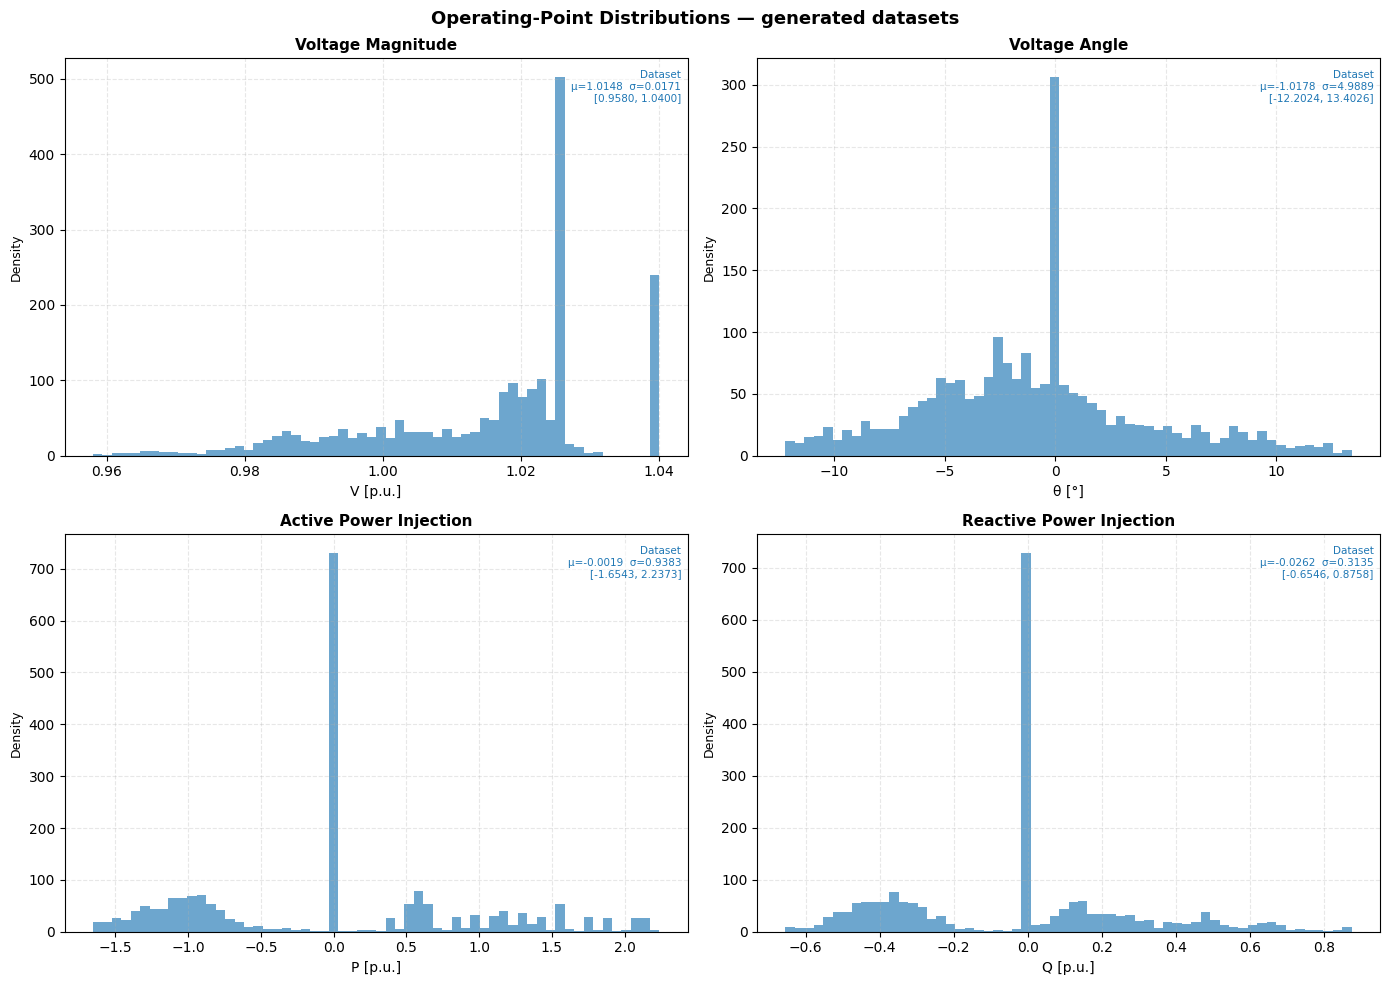

In [122]:
# ── IEEE 9-bus ─────────────────────────────────────────────────────────
networks_ieee9_test_singel_slack=generate_training_data_with_topology(
    num_scenarios=10,
    steps_per_scenario=24,
    seed=42,
    base_system="ieee9",
    line_modification_prob=0.3,
    line_param_variation=0.15,
    enable_extended_topology=True,
    extra_bus_prob=0.5,
    extended_bus_prob=0.3,
    distribute_slack_flag=False,
    distributed_slack_mode="proportional",
    verbose=False,
    volatility_range=0.5,
    load_bias=0.25,
    v_max_ceil=1.2,
    v_min_floor=0.8,
    qp_max=0.66,
    pypsa_logger_level=logging.ERROR,
    v_set_low=0.05,
    v_set_high=0.15,
)
#save_dataset_list(networks_ieee9_mega_singel_slack, os.path.join(TRAINING_RESULTS_DIR, "ieee9_mega.json"), tag="ieee9_mega", subfolder="ieee9_mega")


fig_dist = plot_dataset_distributions(networks_ieee9_test_singel_slack, n_bins=60, suptitle="Operating-Point Distributions — generated datasets",)
plt.show()

In [ ]:
# ── CIGRE14 ─────────────────────────────────────────────────────────────
networks_cigre14_test_singel_slack=generate_training_data_with_topology(
    num_scenarios=100,
    steps_per_scenario=24,
    seed=42,
    base_system="cigre14",
    line_modification_prob=0.3,
    line_param_variation=0.15,
    enable_extended_topology=True,
    extra_bus_prob=0.5, #only used in base s
    extended_bus_prob=0.3,# only used in base s
    max_extra_buses = 3,
    extra_bus_load_prob = 0.7,       
    extra_bus_gen_prob = 0.3,  
    distribute_slack_flag=False,
    distributed_slack_mode="proportional",
    volatility_range=2,
    v_max_ceil=1.2,
    v_min_floor=0.8,
    qp_max=0.66,
    verbose=False
)
#save_dataset_list(networks_cigre14_mega_singel_slack, os.path.join(TRAINING_RESULTS_DIR, "cigre14_mega.json"), tag="cigre14_mega", subfolder="cigre14_mega")#

fig_dist = plot_dataset_distributions(networks_cigre14_test_singel_slack, n_bins=60, suptitle="Operating-Point Distributions — generated datasets",)
plt.show()

     10% | 10/100 networks | attempt 10 | success rate 100%
     20% | 20/100 networks | attempt 20 | success rate 100%
     30% | 30/100 networks | attempt 30 | success rate 100%
     40% | 40/100 networks | attempt 40 | success rate 100%
     50% | 50/100 networks | attempt 50 | success rate 100%
     60% | 60/100 networks | attempt 60 | success rate 100%
     70% | 70/100 networks | attempt 70 | success rate 100%
     80% | 80/100 networks | attempt 80 | success rate 100%
     90% | 90/100 networks | attempt 90 | success rate 100%
    100% | 100/100 networks | attempt 100 | success rate 100%
  Dataset summary (100 networks):
    n_buses   : min=15  mean=16.4  max=18
    Vmag [pu] : min=0.873  mean=0.978  max=1.038  std=0.029  Q1=0.957  Q3=1.001
    Vang [deg]: min=-17.1  mean=-5.8  max=12.6 std=3.3  Q1=-7.8  Q3=-4.2
    Load P[pu]: min=0.000  mean=0.024  max=0.375  std=0.057  Q1=0.001  Q3=0.010
    Load Q[pu]: min=0.000  mean=0.006  max=0.076  std=0.012  Q1=0.000  Q3=0.003
    Load 

### IEEE30 dataset generation

ERROR:__main__:Attempt 1 failed — RuntimeError: ieee30: Voltages out of range (0.7-1.3) after PF


      7% | 1/15 networks | attempt 2 | success rate 50%


ERROR:__main__:Attempt 3 failed — RuntimeError: ieee30: non-finite bus voltages after PF


     13% | 2/15 networks | attempt 4 | success rate 50%
     20% | 3/15 networks | attempt 5 | success rate 60%


ERROR:__main__:Attempt 6 failed — RuntimeError: ieee30: Voltages out of range (0.7-1.3) after PF


...

     60% | 9/15 networks | attempt 13 | success rate 69%
     67% | 10/15 networks | attempt 14 | success rate 71%
     73% | 11/15 networks | attempt 15 | success rate 73%


ERROR:__main__:Attempt 16 failed — RuntimeError: ieee30: Voltages out of range (0.7-1.3) after PF
ERROR:__main__:Attempt 17 failed — RuntimeError: ieee30: non-finite bus voltages after PF
ERROR:__main__:Attempt 18 failed — RuntimeError: ieee30: Voltages out of range (0.7-1.3) after PF
ERROR:__main__:Attempt 19 failed — RuntimeError: ieee30: Voltages out of range (0.7-1.3) after PF
ERROR:__main__:Attempt 20 failed — RuntimeError: ieee30: Voltages out of range (0.7-1.3) after PF
ERROR:__main__:Attempt 21 failed — RuntimeError: ieee30: non-finite bus voltages after PF


     80% | 12/15 networks | attempt 22 | success rate 55%
     87% | 13/15 networks | attempt 23 | success rate 57%
     93% | 14/15 networks | attempt 24 | success rate 58%


ERROR:__main__:Attempt 25 failed — RuntimeError: ieee30: Voltages out of range (0.7-1.3) after PF


    100% | 15/15 networks | attempt 26 | success rate 58%
  Dataset summary (15 networks):
    n_buses   : min=30  mean=31.9  max=34
    Vmag [pu] : min=0.728  mean=0.957  max=1.140  std=0.070  Q1=0.912  Q3=1.012
    Vang [deg]: min=-28.3  mean=-10.9  max=71.8 std=11.5  Q1=-17.1  Q3=-10.3
    Load P[pu]: min=0.006  mean=0.130  max=1.691  std=0.201  Q1=0.032  Q3=0.124
    Load Q[pu]: min=0.001  mean=0.057  max=0.539  std=0.074  Q1=0.013  Q3=0.077
    Load Q/P  : min=0.112  mean=0.450  max=1.000  std=0.213  Q1=0.281  Q3=0.640


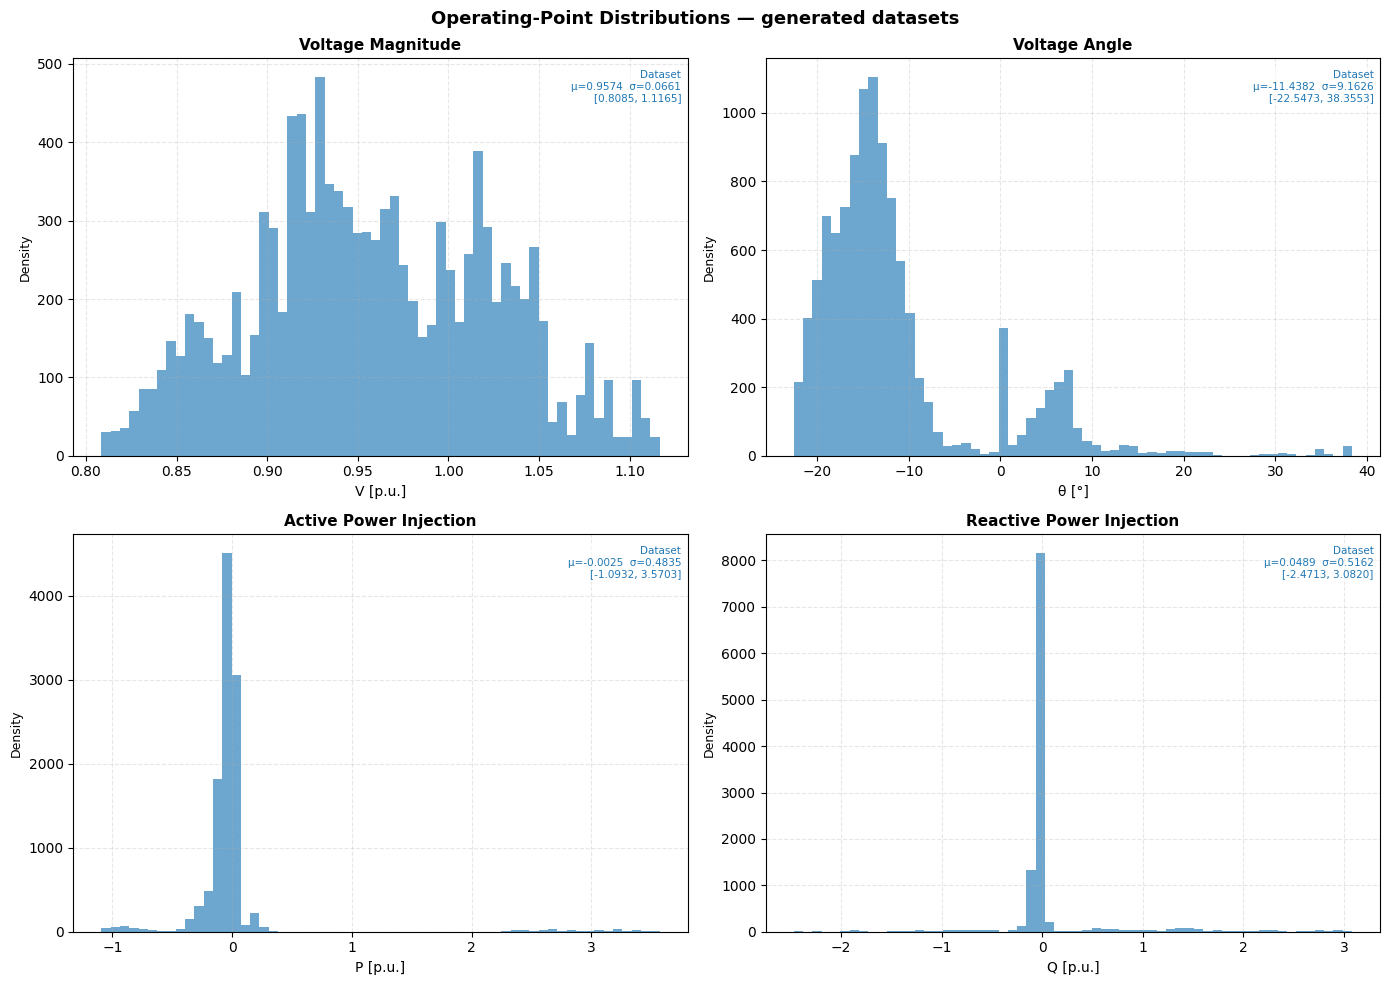

In [119]:
# ── IEEE 30-bus ─────────────────────────────────────────────────────────
networks_ieee30_test_singel_slack=generate_training_data_with_topology(
    num_scenarios=15,
    steps_per_scenario=24,
    seed=42,
    base_system="ieee30",
    volatility_range=0.5,
    load_bias=0.3,   
    v_set_low=0.05,
    v_set_high=0.10,
    line_modification_prob=0.3,
    line_param_variation=0.15,
    enable_extended_topology=True,
    extra_bus_prob=0.5,
    extended_bus_prob=0.0,
    extra_bus_load_prob = 0.7,       
    extra_bus_gen_prob = 0.3,  
    max_extra_buses=5,
    line_disable_prob = 0.0,
    v_max_ceil=1.3,
    v_min_floor=0.7,
    qp_max=1.5,
    distribute_slack_flag=False,
    distributed_slack_mode="proportional",
    verbose=False,
    grid_dir=GRID_MODEL_FILES, 
    pypsa_logger_level=logging.ERROR 
)
#save_dataset_list(networks_ieee30_mega_singel_slack, os.path.join(TRAINING_RESULTS_DIR, "ieee30_mega.json"), tag="ieee30_mega", subfolder="ieee30_mega")
# ── Dataset distribution plots ────────────────────────────────────────

fig_dist = plot_dataset_distributions(networks_ieee30_test_singel_slack, n_bins=60, suptitle="Operating-Point Distributions — generated datasets",)
plt.show()

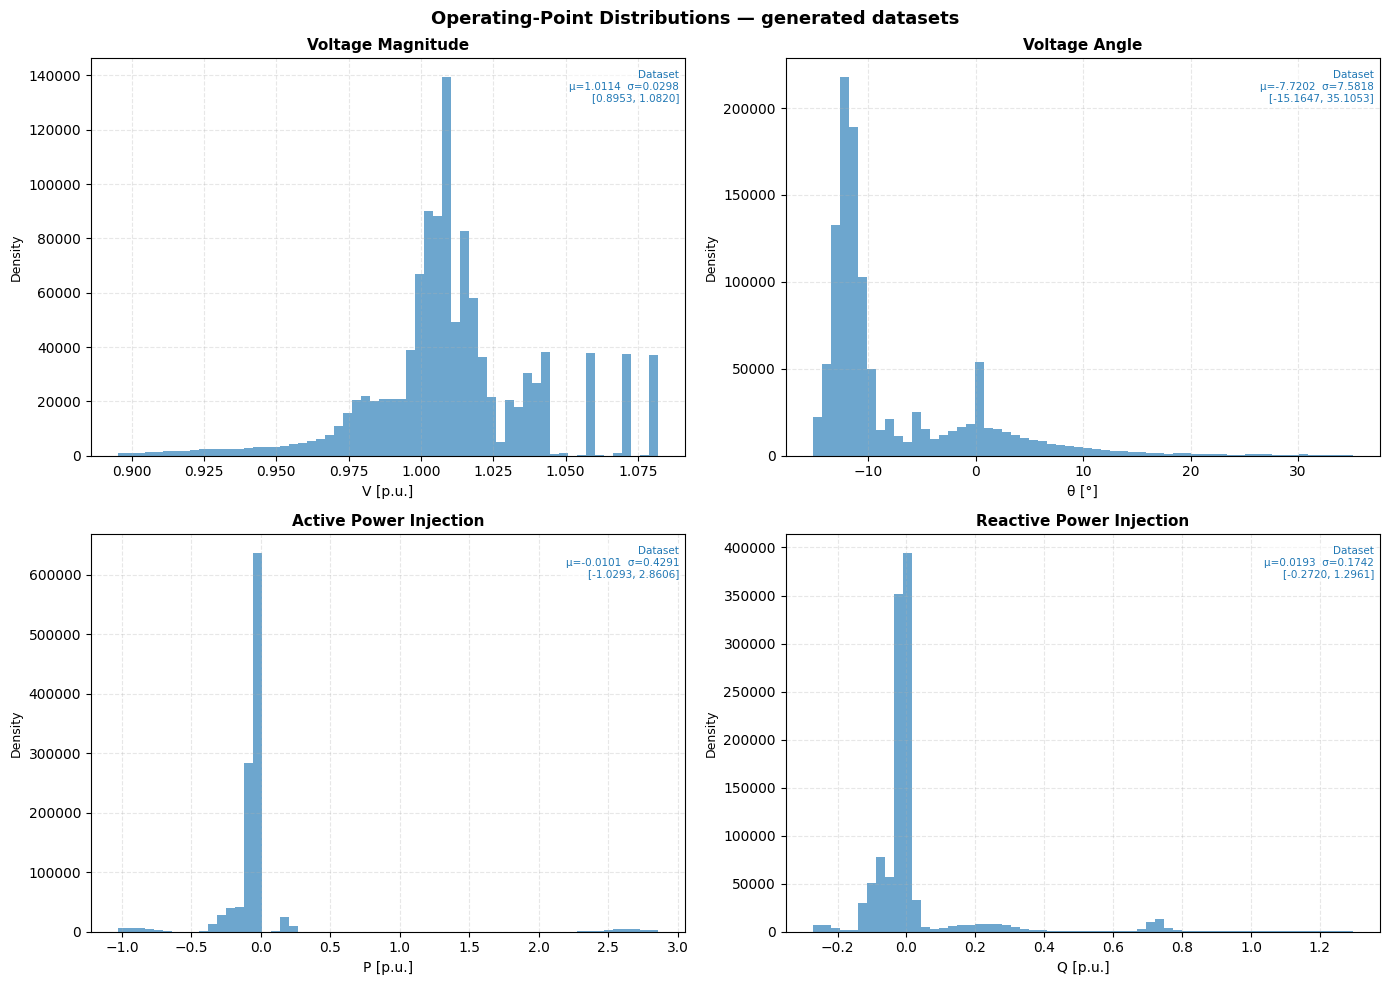

In [73]:

fig_dist = plot_dataset_distributions(
    networks_ieee30_mega_singel_slack,
    n_bins=60,
    suptitle="Operating-Point Distributions — generated datasets",
)
plt.show()

### IEEE57 dataset generation

In [ ]:
# ── IEEE 57-bus ─────────────────────────────────────────────────────────
networks_ieee57_test_singel_slack=generate_training_data_with_topology(
    num_scenarios=10,
    steps_per_scenario=24,
    seed=42,
    base_system="ieee57",
    volatility_range=0.15,
    line_modification_prob=0.3,
    line_param_variation=0.15,
    enable_extended_topology=True,
    extra_bus_prob=0.2,
    extended_bus_prob=0.0,
    extra_bus_load_prob = 0.7,       
    extra_bus_gen_prob = 0.3,  
    max_extra_buses=5,
    line_disable_prob = 0.0,
    v_max_ceil=1.3,
    v_min_floor=0.7,
    #qp_max=2,
    distribute_slack_flag=False,
    distributed_slack_mode="proportional",
    verbose=False,
    grid_dir=GRID_MODEL_FILES,  
)
#save_dataset_list(networks_ieee57_mega_singel_slack, os.path.join(TRAINING_RESULTS_DIR, "ieee57_mega.json"), tag="ieee57_mega", subfolder="ieee57_mega")

     10% | 1/10 networks | attempt 1 | success rate 100%
     20% | 2/10 networks | attempt 2 | success rate 100%
     30% | 3/10 networks | attempt 3 | success rate 100%
     40% | 4/10 networks | attempt 4 | success rate 100%


ERROR:__main__:Attempt 5 failed — RuntimeError: ieee57: non-finite bus voltages after PF
ERROR:__main__:Attempt 6 failed — RuntimeError: failed to factorize matrix at line 406 in file ../scipy/sparse/linalg/_dsolve/SuperLU/SRC/dpanel_bmod.c



     50% | 5/10 networks | attempt 7 | success rate 71%
     60% | 6/10 networks | attempt 8 | success rate 75%
  Rejected scenario 9 due to voltage out of range: Vmin=0.731, Vmax=1.040
     70% | 7/10 networks | attempt 10 | success rate 70%
  Rejected scenario 11 due to voltage out of range: Vmin=0.800, Vmax=1.040
     80% | 8/10 networks | attempt 12 | success rate 67%


ERROR:__main__:Attempt 13 failed — RuntimeError: ieee57: non-finite bus voltages after PF


     90% | 9/10 networks | attempt 14 | success rate 64%
    100% | 10/10 networks | attempt 15 | success rate 67%
  Dataset summary (10 networks):
    n_buses   : min=57  mean=57.6  max=59
    Vmag [pu] : min=0.801  mean=0.937  max=1.040  std=0.050  Q1=0.903  Q3=0.976
    Vang [deg]: min=-24.8  mean=-11.2  max=31.4 std=5.5  Q1=-14.2  Q3=-8.6
    Load P[pu]: min=0.014  mean=0.296  max=4.316  std=0.617  Q1=0.051  Q3=0.225
    Load Q[pu]: min=0.004  mean=0.079  max=1.007  std=0.141  Q1=0.020  Q3=0.086
    Load Q/P  : min=0.027  mean=1.035  max=29.333  std=4.406  Q1=0.215  Q3=0.500


### IEEE118 dataset generation

In [60]:
# ── IEEE 118-bus ─────────────────────────────────────────────────────────
networks_ieee118_test_singel_slack=generate_training_data_with_topology(
    num_scenarios=10,
    steps_per_scenario=24,
    seed=42,
    base_system="ieee118",
    volatility_range=0.15,
    line_modification_prob=0.3,
    line_param_variation=0.15,
    enable_extended_topology=True,
    extra_bus_prob=0.2,
    extended_bus_prob=0.0,
    extra_bus_load_prob = 0.7,       
    extra_bus_gen_prob = 0.3,  
    max_extra_buses=5,
    line_disable_prob = 0.0,
    v_max_ceil=1.2,
    v_min_floor=0.8,
    qp_max=2,
    distribute_slack_flag=False,
    distributed_slack_mode="proportional",
    verbose=False,
    grid_dir=GRID_MODEL_FILES,  
)
#save_dataset_list(networks_ieee118_mega_singel_slack, os.path.join(TRAINING_RESULTS_DIR, "ieee118_mega.json"), tag="ieee118_mega", subfolder="ieee118_mega")

     10% | 1/10 networks | attempt 1 | success rate 100%
     20% | 2/10 networks | attempt 2 | success rate 100%
     30% | 3/10 networks | attempt 3 | success rate 100%
     40% | 4/10 networks | attempt 4 | success rate 100%
     50% | 5/10 networks | attempt 5 | success rate 100%
     60% | 6/10 networks | attempt 6 | success rate 100%
     70% | 7/10 networks | attempt 7 | success rate 100%
     80% | 8/10 networks | attempt 8 | success rate 100%
     90% | 9/10 networks | attempt 9 | success rate 100%
    100% | 10/10 networks | attempt 10 | success rate 100%
  Dataset summary (10 networks):
    n_buses   : min=118  mean=118.7  max=120
    Vmag [pu] : min=0.940  mean=0.986  max=1.050  std=0.023  Q1=0.967  Q3=0.999
    Vang [deg]: min=-19.6  mean=11.7  max=93.8 std=14.9  Q1=1.9  Q3=17.2
    Load P[pu]: min=0.017  mean=0.427  max=3.183  std=0.399  Q1=0.179  Q3=0.561
    Load Q[pu]: min=0.000  mean=0.145  max=1.298  std=0.144  Q1=0.052  Q3=0.222
    Load Q/P  : min=0.000  mean=0.363

## Regression & Unit Tests
_(optional — verify data-gen correctness)_

In [ ]:
# ── Regression gate ────────────────────────────────────────────
BASELINE = {
    "vmag_mae": 0.003889,
    "vang_mae": 0.015385,   
    "p_mae":    0.003059,
    "q_mae":    0.007242,
}
BASELINE_CONFIG = {
    "physics_mode":     "rich",
    "weight_physics":   0.04,
    "use_pnet_balance": True,
    "use_q_partial":    False,
    "weight_ptdf":      0.0,
}
TOLERANCE = 0.5

def check_regression(metrics: dict, label: str) -> bool:
    print(f"\n=== REGRESSION CHECK: {label} ===")
    print(f"    Config: {BASELINE_CONFIG}")
    passed = True
    for k, baseline_val in BASELINE.items():
        actual = metrics.get(k)
        if actual is None:
            print(f"  ⚠️  {k:<16} NOT FOUND in metrics dict")
            passed = False
            continue
        pct_change = (actual - baseline_val) / baseline_val
        ok = abs(pct_change) <= TOLERANCE
        status = "✅" if ok else "❌"
        print(f"  {status} {k:<16} actual={actual:.6f}  "
              f"baseline={baseline_val:.6f}  "
              f"diff={pct_change:+.1%}")
        if not ok:
            passed = False
    print(f"\n  Overall: {'PASS ✅' if passed else 'FAIL ❌'}")
    return passed

def run_full_regression_test(
    *,
    run_unit_tests=True,
    num_scenarios=50,
    steps_per_scenario=15,
    seed=42,
    num_epochs=50,
    batch_size=32,
    lr=1e-3,
    conv_type="gatv2",
    hidden_dim=64,
    num_layers=3,
    y_matrix_source="manual",
    warmup_epochs=10,
    verbose=True,

    # dataset generation knobs
    base_system="ieee9",
    distribute_slack_flag=True,
    distributed_slack_mode="proportional",
    enable_extended_topology=True,
    extended_bus_prob=0.2,
    line_modification_prob=0.3,
    line_param_variation=0.15,

    # dataset construction knobs
    use_edge_features=True,
    use_pnet_balance=True,

    # whether to return trained model/history
    return_model=True,
):
    """
    Regression test for dataset-generation / training changes.

    Workflow
    --------
    1) Regenerate networks with fixed seed
    2) Rebuild train/val/test datasets
    3) Run dataset integrity tests
    4) Train a fresh model using baseline accepted config
    5) Evaluate test metrics
    6) Run regression gate + angle-sign gate

    Returns
    -------
    dict with:
        passed                : bool
        metrics               : dict
        test_metrics_trainfn  : dict
        history               : dict or None
        model                 : trained model or None
        networks              : generated network list
        splits                : dict(train/val/test networks)
        datasets              : dict(train/val/test datasets)
        sign_match_10bus      : float or None
        regression_passed     : bool
        angle_sign_passed     : bool or None
        baseline_config       : dict
        generation_config     : dict
        train_config          : dict
    """
    import random
    import numpy as np
    import torch
    import logging as _logging

    print("\n" + "=" * 80)
    print("DATASET REGENERATION REGRESSION TEST")
    print("=" * 80)

    _loggers_to_silence = [
        _logging.getLogger(),          # root
        _logging.getLogger("__main__"),
        _logging.getLogger("pypsa"),
        _logging.getLogger("pypsa.pf"),
        _logging.getLogger("pypsa.components"),
        _logging.getLogger("linopy"),
        _logging.getLogger("numexpr"),
    ]
    _saved_levels = [lg.level for lg in _loggers_to_silence]

    try:
        if not verbose:
            for lg in _loggers_to_silence:
                lg.setLevel(_logging.ERROR)

        # ------------------------------------------------------------------
        # 0. Fixed accepted baseline config
        # ------------------------------------------------------------------
        baseline_cfg = PhysicsConfig(
            w_phys=0.04,
            physics_mode="rich",
            use_power_balance=True,
            use_angle_ref_penalty=True,
            use_q_partial_mode=False,
            use_ptdf_loss=False,
            weight_ptdf=0.0,
            ptdf_loss_mode="matrix",
            ptdf_alpha=0.5,
            ptdf_branch_mode="lines",
        )

        generation_config = {
            "num_scenarios": num_scenarios,
            "steps_per_scenario": steps_per_scenario,
            "seed": seed,
            "base_system": base_system,
            "distribute_slack_flag": distribute_slack_flag,
            "distributed_slack_mode": distributed_slack_mode,
            "enable_extended_topology": enable_extended_topology,
            "extended_bus_prob": extended_bus_prob,
            "line_modification_prob": line_modification_prob,
            "line_param_variation": line_param_variation,
        }

        train_config = {
            "num_epochs": num_epochs,
            "batch_size": batch_size,
            "lr": lr,
            "conv_type": conv_type,
            "hidden_dim": hidden_dim,
            "num_layers": num_layers,
            "y_matrix_source": y_matrix_source,
            "warmup_epochs": warmup_epochs,
            "use_edge_features": use_edge_features,
            "use_pnet_balance": use_pnet_balance,
            "physics": {
                "w_phys": baseline_cfg.w_phys,
                "physics_mode": baseline_cfg.physics_mode,
                "use_power_balance": baseline_cfg.use_power_balance,
                "use_angle_ref_penalty": baseline_cfg.use_angle_ref_penalty,
                "use_q_partial_mode": baseline_cfg.use_q_partial_mode,
                "use_ptdf_loss": baseline_cfg.use_ptdf_loss,
                "weight_ptdf": baseline_cfg.weight_ptdf,
                "ptdf_loss_mode": baseline_cfg.ptdf_loss_mode,
                "ptdf_alpha": baseline_cfg.ptdf_alpha,
                "ptdf_branch_mode": baseline_cfg.ptdf_branch_mode,
            },
        }

        print("\n[1/6] Regenerating networks...")
        print("Generation config:", generation_config)

        # ------------------------------------------------------------------
        # 1. Deterministic seeds
        # ------------------------------------------------------------------
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        # ------------------------------------------------------------------
        # 2. Regenerate dataset source networks
        # ------------------------------------------------------------------
        new_networks = generate_training_data_with_topology(
            num_scenarios=num_scenarios,
            steps_per_scenario=steps_per_scenario,
            p_set_base={"gen2": 1.63, "gen3": 0.85},
            volatility_range=0.7,
            gen_bus_options=[
                [1, 2, 3],
                [3, 2, 1],
                [4, 5, 6],
                [6, 7, 9],
                [2, 4, 6],
            ],
            load_bus_options=[
                [5, 7, 9],
                [7, 8, 9],
                [4, 6, 8],
                [1, 3, 5, 7, 9],
                [2, 4, 6],
                [3, 5, 7],
                [1, 4, 7],
                [2, 5, 8],
                [3, 6, 9],
                [1, 5, 9],
                [2, 6, 8],
                [4, 7, 9],
            ],
            seed=seed,
            verbose=verbose,
            distribute_slack_flag=distribute_slack_flag,
            distributed_slack_mode=distributed_slack_mode,
            base_system=base_system,
            enable_extended_topology=enable_extended_topology,
            extended_bus_prob=extended_bus_prob,
            line_modification_prob=line_modification_prob,
            line_param_variation=line_param_variation,
        )

        print(f"Generated {len(new_networks)} networks")

        # ------------------------------------------------------------------
        # 3. Recreate exact split for unit tests and sign checks
        # ------------------------------------------------------------------
        print("\n[2/6] Building train/val/test split and datasets...")

        networks_copy = new_networks.copy()
        random.seed(seed)
        random.shuffle(networks_copy)

        num_train_networks = int(0.7 * len(networks_copy))
        num_val_networks = int(0.85 * len(networks_copy)) - num_train_networks

        train_networks = networks_copy[:num_train_networks]
        val_networks = networks_copy[num_train_networks:num_train_networks + num_val_networks]
        test_networks = networks_copy[num_train_networks + num_val_networks:]

        print(
            f"Network split: Train={len(train_networks)}, "
            f"Val={len(val_networks)}, Test={len(test_networks)}"
        )

        train_dataset = PowerFlowDataset(
            train_networks,
            use_edge_features=use_edge_features,
            use_pnet_balance=use_pnet_balance,
            ptdf_branch_mode=baseline_cfg.ptdf_branch_mode,
        )
        val_dataset = PowerFlowDataset(
            val_networks,
            use_edge_features=use_edge_features,
            use_pnet_balance=use_pnet_balance,
            ptdf_branch_mode=baseline_cfg.ptdf_branch_mode,
        )
        test_dataset = PowerFlowDataset(
            test_networks,
            use_edge_features=use_edge_features,
            use_pnet_balance=use_pnet_balance,
            ptdf_branch_mode=baseline_cfg.ptdf_branch_mode,
        )

        # ------------------------------------------------------------------
        # 4. Dataset integrity tests
        # ------------------------------------------------------------------
        print("\n[3/6] Running dataset integrity tests...")
        if run_unit_tests:
            run_all_unit_tests(train_dataset, val_dataset, test_dataset)

        # ------------------------------------------------------------------
        # 5. Train fresh model with baseline accepted config
        # ------------------------------------------------------------------
        print("\n[4/6] Training fresh model on regenerated dataset...")
        print("Training config:", train_config)

        model, history, test_metrics_trainfn = train_power_flow_gnn(
            networks=new_networks,
            num_epochs=num_epochs,
            batch_size=batch_size,
            lr=lr,
            conv_type=conv_type,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            physics_cfg=baseline_cfg,
            use_edge_features=use_edge_features,
            use_pnet_balance=use_pnet_balance,
            seed=seed,
            y_matrix_source=y_matrix_source,
            warmup_epochs=warmup_epochs,
        )

        # ------------------------------------------------------------------
        # 6. Independent evaluation + regression gate
        # ------------------------------------------------------------------
        print("\n[5/6] Evaluating trained model on test split...")
        eval_metrics = evaluate_gnn_on_test_set(
            model,
            test_networks=test_networks,
            use_edge_features=use_edge_features,
            use_pnet_balance=use_pnet_balance,
        )

        print("\nIndependent evaluation metrics:")
        for k, v in eval_metrics.items():
            if isinstance(v, (float, int)):
                print(f"  {k:<20} {v:.6f}")
            else:
                print(f"  {k:<20} {v}")

        print("\n[6/6] Running regression gates...")
        regression_passed = check_regression(
            eval_metrics,
            label="Dataset regeneration regression test",
        )

        sign_match = check_angle_sign_10bus(model, test_dataset)
        angle_sign_passed = (sign_match is not None and sign_match > 0.85)

        if sign_match is None:
            print("⚠️  Angle-sign test sample not found; treating angle-sign gate as inconclusive.")
        else:
            print(f"Angle-sign gate: {'PASS ✅' if angle_sign_passed else 'FAIL ❌'}")

        passed = regression_passed and (angle_sign_passed if sign_match is not None else True)

        print("\n" + "=" * 80)
        print(f"OVERALL REGRESSION RESULT: {'PASS ✅' if passed else 'FAIL ❌'}")
        print("=" * 80)

        # ------------------------------------------------------------------
        # Build run-style dict compatible with sweep / plotting
        # ------------------------------------------------------------------
        run_dict = {
            # Core hyperparameters / labels
            "weight_physics": train_config["physics"]["w_phys"],
            "weight_ptdf": train_config["physics"]["weight_ptdf"],
            "physics_mode": train_config["physics"]["physics_mode"],
            "physics_label": baseline_cfg.label() if hasattr(baseline_cfg, "label") else "baseline",
            "use_power_balance": train_config["physics"]["use_power_balance"],
            "use_angle_ref_penalty": train_config["physics"]["use_angle_ref_penalty"],
            "use_q_partial_mode": train_config["physics"]["use_q_partial_mode"],
            "use_ptdf_loss_flag": train_config["physics"]["use_ptdf_loss"],
            "ptdf_loss_mode": train_config["physics"]["ptdf_loss_mode"],
            "ptdf_alpha": train_config["physics"]["ptdf_alpha"],
            "ptdf_branch_mode": train_config["physics"]["ptdf_branch_mode"],
            "y_matrix_source": y_matrix_source,
            "batch_size": batch_size,
            "lr": lr,
            "hidden_dim": hidden_dim,
            "num_layers": num_layers,
            "conv_type": conv_type,
            "warmup_epochs": warmup_epochs,
            "seed": seed,

            # Outputs expected by plotting / analysis
            "history": history,
            "model": model if return_model else None,
            "test_metrics": {
                "overall_metrics": {
                    "vmag_mae": {
                        "mean": float(eval_metrics.get("vmag_mae", float("nan"))),
                        "std": 0.0,
                    },
                    "vang_mae": {
                        "mean": float(eval_metrics.get("vang_mae", float("nan"))),
                        "std": 0.0,
                    },
                    "vang_rmse": {
                        "mean": float(eval_metrics.get("vang_rmse", float("nan"))),
                        "std": 0.0,
                    },
                    "p_mae": {
                        "mean": float(eval_metrics.get("p_mae", float("nan"))),
                        "std": 0.0,
                    },
                    "q_mae": {
                        "mean": float(eval_metrics.get("q_mae", float("nan"))),
                        "std": 0.0,
                    },
                },
                "test_total": float(test_metrics_trainfn.get("test_total", float("nan"))),
                "test_mse": float(test_metrics_trainfn.get("test_mse", float("nan"))),
                "test_physics": float(test_metrics_trainfn.get("test_physics", float("nan"))),
                "test_ptdf": float(test_metrics_trainfn.get("test_ptdf", float("nan"))),
            },

            # Extra diagnostics
            "metrics": eval_metrics,
            "eval_metrics_raw": eval_metrics,
            "test_metrics_trainfn": test_metrics_trainfn,
            "sign_match_10bus": sign_match,
            "regression_passed": regression_passed,
            "angle_sign_passed": angle_sign_passed,
            "passed": passed,
            "baseline_config": {
                "physics_mode": baseline_cfg.physics_mode,
                "weight_physics": baseline_cfg.w_phys,
                "use_pnet_balance": use_pnet_balance,
                "use_q_partial": baseline_cfg.use_q_partial_mode,
                "weight_ptdf": baseline_cfg.weight_ptdf,
                "ptdf_loss_mode": baseline_cfg.ptdf_loss_mode,
                "ptdf_alpha": baseline_cfg.ptdf_alpha,
                "ptdf_branch_mode": baseline_cfg.ptdf_branch_mode,
            },
            "generation_config": generation_config,
            "train_config": train_config,
            "networks": new_networks,
            "splits": {
                "train_networks": train_networks,
                "val_networks": val_networks,
                "test_networks": test_networks,
            },
            "datasets": {
                "train_dataset": train_dataset,
                "val_dataset": val_dataset,
                "test_dataset": test_dataset,
            },
        }

        return run_dict

    finally:
        for lg, lvl in zip(_loggers_to_silence, _saved_levels):
            lg.setLevel(lvl)

# ── Angle sign regression sample ───────────────────────────────
def check_angle_sign_10bus(model, test_dataset):
    """Run after every phase. Acceptance: sign_match > 85%."""
    model.eval()
    with torch.no_grad():
        for i in range(len(test_dataset)):
            s = test_dataset[i]
            if s.num_nodes == 10 and s.slack_mask[2].item():
                non_slack_y = s.y[:, 1][~s.slack_mask]
                if (non_slack_y < 0).any():
                    pred = model(s)
                    # model(s) returns (node_pred, ...) — unwrap if tuple
                    if isinstance(pred, tuple):
                        pred = pred[0]
                    y = s.y[:, 1]
                    p = pred[:, 1]
                    non_zero = y.abs() > 1e-4
                    sign_match = ((y[non_zero] * p[non_zero]) > 0).float().mean()
                    result = "✅" if sign_match > 0.85 else "❌"
                    print(f"{result} Sign match (10-bus Bus-3-slack): {sign_match:.1%}  "
                          f"(threshold 85%)")
                    return sign_match.item()
    print("⚠️  No matching 10-bus Bus-3-slack sample with negative angles found.")
    return None

In [ ]:
# ── Unit tests ─────────────────────────────────────────────────
def test_bus_order_alignment(dataset, n=10):
    """
    Guard against gross bus reordering (e.g. Bus 1,10,2,3).
    We use a very lenient rank-correlation and log info on outliers.
    """
    import random, numpy as np
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))

    for i in indices:
        d = dataset[i]
        p_in  = d.x[:, 3].cpu().numpy()
        p_out = d.y[:, 2].cpu().numpy()

        # skip trivial all-zero cases
        if (np.abs(p_in) < 1e-6).all() and (np.abs(p_out) < 1e-6).all():
            continue

        ranks_in  = np.argsort(np.argsort(p_in))
        ranks_out = np.argsort(np.argsort(p_out))
        corr = np.corrcoef(ranks_in, ranks_out)[0, 1]

        if corr < 0.5:
            raise AssertionError(
                f"Sample {i}: rank correlation between P_in and P_out is {corr:.2f} "
                f"— this looks like a bus-order mismatch."
            )
        elif corr < 0.8:
            print(f"⚠️  Sample {i}: low-ish rank corr {corr:.2f} "
                  f"(likely strong re-dispatch, not a bug)")

    print("✅ test_bus_order_alignment passed")

def test_angle_sign_coverage(dataset):
    """Every (n_buses, slack_bus) group must have >10% negative angles."""
    from collections import defaultdict
    groups = defaultdict(list)
    for i in range(len(dataset)):
        d = dataset[i]
        slack_idx = d.slack_mask.nonzero(as_tuple=True)[0]
        if len(slack_idx) == 0:
            continue
        key = (d.num_nodes, slack_idx[0].item())
        non_slack_ang = d.y[:, 1][~d.slack_mask]
        groups[key].extend(non_slack_ang.tolist())

    failures = []
    for key, angles in groups.items():
        angles_t = torch.tensor(angles)
        frac_neg = (angles_t < 0).float().mean().item()
        if frac_neg <= 0.1:
            failures.append((key, frac_neg))

    if failures:
        for key, frac in failures:
            print(f"  ❌ group {key}: frac_neg={frac:.3f} (must be >0.10)")
        raise AssertionError("test_angle_sign_coverage FAILED — some groups lack negative angles")
    print("✅ test_angle_sign_coverage passed")


def test_feature_dim_consistency(train_ds, val_ds, test_ds):
    dims = {
        "train": train_ds[0].x.size(1),
        "val":   val_ds[0].x.size(1),
        "test":  test_ds[0].x.size(1),
    }
    assert len(set(dims.values())) == 1, \
        f"Feature dim mismatch across splits: {dims}"
    print(f"✅ test_feature_dim_consistency passed  (x.size(1)={dims['train']})")


def test_slack_input_zeroing(dataset, n=20):
    import random
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    for i in indices:
        d = dataset[i]
        # Vang column (col 1) must be 0 at slack
        slack_vang = d.x[d.slack_mask, 1]
        assert (slack_vang.abs() < 1e-6).all(), \
            f"Sample {i}: slack vang not zeroed — {slack_vang}"
        # P column (col 3) must be 0 at slack (masked input)
        slack_p = d.x[d.slack_mask, 3]
        assert (slack_p.abs() < 1e-6).all(), \
            f"Sample {i}: slack P input not zeroed — {slack_p}"
    print("✅ test_slack_input_zeroing passed")


def test_pnet_balance_nonzero(dataset, n=20):
    import random
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    for i in indices:
        d = dataset[i]
        if hasattr(d, 'p_net_balance'):
            assert d.p_net_balance.abs().item() > 1e-9, \
                f"Sample {i}: p_net_balance is zero — use_pnet_balance may be off"
    print("✅ test_pnet_balance_nonzero passed (or attribute absent)")


def test_angle_sign_10bus_regression(test_dataset, threshold=0.85):
    from collections import defaultdict
    sign_matches = []
    for i in range(len(test_dataset)):
        d = test_dataset[i]
        if d.num_nodes != 10:
            continue
        ang = d.y[:, 1]
        non_slack = ~d.slack_mask
        frac_neg = (ang[non_slack] < 0).float().mean().item()
        sign_matches.append(frac_neg)
    if not sign_matches:
        print("⚠️  No 10-bus samples found.")
        return
    mean_neg = sum(sign_matches) / len(sign_matches)
    ok = mean_neg > 0.1
    status = "✅" if ok else "❌"
    print(f"{status} test_angle_sign_10bus_regression: "
          f"mean frac_neg_angle={mean_neg:.3f} across {len(sign_matches)} 10-bus samples")


def test_no_slack_angle_leakage(train_ds, val_ds, test_ds):
    for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
        for i in range(len(ds)):
            d = ds[i]
            if d.slack_mask.any():
                vang_slack = d.x[d.slack_mask, 1]
                assert (vang_slack.abs() < 1e-6).all(), \
                    f"{name}[{i}]: slack vang leakage — {vang_slack}"
    print("✅ test_no_slack_angle_leakage passed")


def test_ptdf_shape(dataset, n=10):
    import random
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    for i in indices:
        d = dataset[i]
        assert hasattr(d, 'y_ptdf'), f"Sample {i}: y_ptdf missing"
        net_idx, t_idx = dataset._index[i]
        net = dataset.networks[net_idx]
        n_lines = len(net.lines)
        n_buses = len(net.buses)
        assert d.ptdf_matrix.shape == (n_lines, n_buses), (
            f"Sample {i}: ptdf_matrix shape {d.ptdf_matrix.shape} "
            f"!= expected ({n_lines}, {n_buses})"
        )
    print("✅ test_ptdf_shape passed")  

def test_collate_ptdf(dataset):
    """Batch 3 graphs; verify PTDF lists and shapes are consistent."""
    # Pick up to 3 samples
    samples = [dataset[i] for i in range(min(3, len(dataset)))]

    # NOTE: collate_with_ptdf returns a single Batch
    batched = collate_with_ptdf(samples)

    assert hasattr(batched, "x"),          "Batch missing x"
    assert hasattr(batched, "edge_index"), "Batch missing edge_index"
    assert hasattr(batched, "y_ptdf_list"), "Batch missing y_ptdf_list"
    assert hasattr(batched, "y_line_p_list"), "Batch missing y_line_p_list"

    y_ptdf_list  = batched.y_ptdf_list
    y_line_p_list = batched.y_line_p_list

    for i, (yptdf, ylinep) in enumerate(zip(y_ptdf_list, y_line_p_list)):
        if yptdf is not None:
            assert yptdf.dim() == 2, f"Graph {i}: yptdf dim {yptdf.shape} not (n_lines, n_buses)"
            assert yptdf.shape[0] > 0 and yptdf.shape[1] > 0, \
                f"Graph {i}: yptdf has non-positive shape {yptdf.shape}"
        if ylinep is not None:
            assert ylinep.dim() == 1, f"Graph {i}: ylinep dim {ylinep.shape} not (n_lines,)"

    print("✅ test_collate_ptdf passed")

def test_ptdf_dc_flows(dataset, tol=1e-3):
    """
    For one sample: PTDF @ delta_p should reproduce PyPSA DC line flows
    within tol p.u.
    """
    for i in range(len(dataset)):
        d = dataset[i]
        if not hasattr(d, 'y_ptdf'):
            continue

        net_idx, t_idx = dataset._index[i]
        net  = dataset.networks[net_idx]
        snap = net.snapshots[t_idx]

        if net.lines_t.p0.empty:
            continue

        # True AC line flows from PyPSA (as reference)
        true_flows = torch.tensor(
            net.lines_t.p0.loc[snap].values, dtype=torch.float
        )

        # Use ground-truth P injections (y[:,2]) as delta_p
        delta_p = d.y[:, 2]

        pred_flows = d.y_ptdf @ delta_p
        max_err = (pred_flows - true_flows).abs().max().item()

        # PTDF is a DC approximation so tolerance is loose
        print(f"  PTDF DC flow test (sample {i}): max_err={max_err:.4f} p.u. "
              f"({'✅' if max_err < tol else '⚠️ DC approx only'})")
        return  # one sample is enough

    print("⚠️  test_ptdf_dc_flows: no valid sample found with lines_t.p0")

def test_angle_ref_loss_per_graph():
    """
    Verify angle_ref_loss > 0 when one graph has slack angle +0.05
    and another has -0.05 (no cancellation from batched mean).
    """
    # Build two minimal fake Data objects
    def fake_graph(slack_ang_val):
        d = Data()
        d.x = torch.zeros(3, 8)
        d.x[0, 6] = slack_ang_val   # col 6 = vang input at slack
        d.y = torch.zeros(3, 4)
        d.slack_mask = torch.tensor([True, False, False])
        d.pv_mask    = torch.tensor([False, True, False])
        d.pq_mask    = torch.tensor([False, False, True])
        d.edge_index = torch.zeros(2, 0, dtype=torch.long)
        d.edge_attr  = torch.zeros(0, 6)
        return d

    from torch_geometric.data import Batch
    d1 = fake_graph(+0.05)
    d2 = fake_graph(-0.05)
    batch = Batch.from_data_list([d1, d2])

    # A correct per-graph implementation should penalise both
    # slack angles independently — combined loss > 0
    # (If batched mean were used, +0.05 and -0.05 would cancel to 0.)

    # Simulate the angle_ref_loss computation from physics_informed_loss_batch
    ptr = batch.ptr
    total = torch.tensor(0.0)
    for g in range(2):
        start, end = ptr[g].item(), ptr[g+1].item()
        slack_g = batch.slack_mask[start:end]
        vang_pred_g = batch.x[start:end, 6]   # using x as proxy for pred
        ref_loss_g  = (vang_pred_g[slack_g] ** 2).mean()
        total = total + ref_loss_g

    assert total.item() > 1e-6, \
        f"test_angle_ref_loss_per_graph FAILED: total={total.item():.6f} — " \
        f"cancellation detected (V2.3 bug reproduced)"
    print(f"✅ test_angle_ref_loss_per_graph passed (total={total.item():.6f})")


def run_all_unit_tests(train_ds, val_ds, test_ds):
    print("\n" + "="*50)
    print("UNIT TESTS")
    print("="*50)
    # --- Permanent structural tests ---
    test_feature_dim_consistency(train_ds, val_ds, test_ds)
    test_slack_input_zeroing(train_ds)
    test_pnet_balance_nonzero(train_ds)
    test_no_slack_angle_leakage(train_ds, val_ds, test_ds)
    test_angle_sign_coverage(train_ds)
    test_bus_order_alignment(train_ds)
    test_angle_ref_loss_per_graph()

    # --- PTDF structural tests (permanent once PTDF is core) ---
    test_collate_ptdf(train_ds)       # second definition only

    # --- Ad-hoc / dev diagnostics (run manually, not in CI suite) ---
    # test_ptdf_shape(train_ds)       # retired: uses old .ptdf_matrix attr
    # test_ptdf_dc_flows(train_ds)    # diagnostic only, not a code invariant
    # test_angle_sign_10bus_regression(test_ds)  # covered by check_angle_sign_10bus
    print("="*50 + "\n")



In [ ]:
# ── data generation unit tests ──────────────────────

def test_build_graph_from_network(net):
    G = nx.Graph()
    for _, line in net.lines.iterrows():
        G.add_edge(line.bus0, line.bus1)
    for _, trafo in net.transformers.iterrows():
        G.add_edge(trafo.bus0, trafo.bus1)
    for bus in net.buses.index:
        G.add_node(bus)
    return G


def test_csv_loader_column_mapping():
    """
    Ensure load_system_from_csv uses the intended CSV columns and p.u. values.
    This directly guards against the v_mag/v_mag_pu regression.
    """
    import os
    import tempfile
    import pandas as pd
    import numpy as np

    with tempfile.TemporaryDirectory() as tmpdir:
        base_name = "toy"

        buses_df = pd.DataFrame(
            {
                "v_mag":    [132.0, 127.0],   # wrong legacy-style values
                "v_mag_pu": [1.02, 0.97],     # correct values that must win
            },
            index=["B1", "B2"]
        )
        buses_df.to_csv(os.path.join(tmpdir, f"{base_name}_buses.csv"))

        lines_df = pd.DataFrame(
            {
                "bus1_id": ["B1"],
                "bus2_id": ["B2"],
                "r": [0.01],
                "x": [0.05],
                "b1": [0.02],
                "b2": [0.02],
            },
            index=["L1"]
        )
        lines_df.to_csv(os.path.join(tmpdir, f"{base_name}_lines.csv"))

        gens_df = pd.DataFrame(
            {
                "bus_id": ["B1"],
                "max_p": [1.0],
                "min_p": [0.0],
                "target_p": [0.5],
                "target_q": [0.0],
                "voltage_regulator_on": [True],
            },
            index=["G1"]
        )
        gens_df.to_csv(os.path.join(tmpdir, f"{base_name}_gens.csv"))

        loads_df = pd.DataFrame(
            {
                "bus_id": ["B2"],
                "p0": [0.4],
                "q0": [0.1],
            },
            index=["LD1"]
        )
        loads_df.to_csv(os.path.join(tmpdir, f"{base_name}_loads.csv"))

        net = load_system_from_csv(base_name=base_name, load_dir=tmpdir)

        got = net.buses.loc[["B1", "B2"], "v_mag_pu_set"].astype(float).values
        exp = np.array([1.02, 0.97])

        assert np.allclose(got, exp, atol=1e-9), \
            f"v_mag_pu mapping failed: expected {exp}, got {got}"

    print("✅ test_csv_loader_column_mapping passed")


def test_csv_loader_static_component_ranges(base_name="ieee39", load_dir=GRID_MODEL_FILES):
    """
    Validate static network tables after CSV import, before PF-dependent checks.
    """
    net = load_system_from_csv(base_name=base_name, load_dir=load_dir)

    # basic presence
    assert len(net.buses) > 0, "No buses loaded"
    assert len(net.generators) > 0, "No generators loaded"
    assert len(net.loads) > 0, "No loads loaded"
    assert len(net.lines) + len(net.transformers) > 0, "No branches loaded"

    # buses
    assert "v_mag_pu_set" in net.buses.columns, "Missing bus v_mag_pu_set"
    assert net.buses["v_mag_pu_set"].notna().all(), "NaN in v_mag_pu_set"
    assert net.buses["v_mag_pu_set"].between(0.8, 1.2).all(), \
        "Bus v_mag_pu_set outside expected p.u. range [0.8, 1.2]"

    # lines
    if len(net.lines) > 0:
        assert net.lines["r"].notna().all(), "NaN line resistance"
        assert net.lines["x"].notna().all(), "NaN line reactance"
        assert (net.lines["r"] >= 0.0).all(), "Negative line resistance"
        assert (net.lines["x"] > 0.0).all(), "Non-positive line reactance"

    # transformers
    if len(net.transformers) > 0:
        assert net.transformers["x"].notna().all(), "NaN transformer reactance"
        assert (net.transformers["x"] > 0.0).all(), "Non-positive transformer reactance"
        if "r" in net.transformers.columns:
            assert (net.transformers["r"] >= 0.0).all(), "Negative transformer resistance"

    # generators
    assert net.generators["p_nom"].notna().all(), "NaN generator p_nom"
    assert (net.generators["p_nom"] > 0.0).all(), "Non-positive generator p_nom"
    if "p_set" in net.generators.columns:
        assert net.generators["p_set"].notna().all(), "NaN generator p_set"
        assert (net.generators["p_set"].abs() < 1e4).all(), "Implausible generator p_set"

    # loads
    assert net.loads["p_set"].notna().all(), "NaN load p_set"
    assert net.loads["q_set"].notna().all(), "NaN load q_set"
    assert (net.loads["p_set"] >= 0.0).all(), "Negative load p_set"
    assert (net.loads["q_set"].abs() < 1e4).all(), "Implausible load q_set"

    print(f"✅ test_csv_loader_static_component_ranges passed ({base_name})")


def test_csv_loader_connectivity_and_controls(base_name="ieee39", load_dir=GRID_MODEL_FILES):
    """
    Validate topology connectivity and control assignment after CSV import.
    """
    net = load_system_from_csv(base_name=base_name, load_dir=load_dir)

    G = test_build_graph_from_network(net)
    assert len(G.nodes) == len(net.buses), \
        f"Connectivity graph missing buses: {len(G.nodes)} vs {len(net.buses)}"

    assert nx.is_connected(G), \
        f"Imported network is disconnected: {nx.number_connected_components(G)} components"

    assert "control" in net.generators.columns, "Generator control column missing"
    slack_gens = net.generators.index[net.generators["control"] == "Slack"]
    pv_gens    = net.generators.index[net.generators["control"] == "PV"]

    assert len(slack_gens) >= 1, "No Slack generator assigned"
    assert len(pv_gens) >= 0, "PV generator parsing failed"

    # Every generator/load bus must exist
    assert net.generators["bus"].isin(net.buses.index).all(), "Generator attached to missing bus"
    assert net.loads["bus"].isin(net.buses.index).all(), "Load attached to missing bus"

    print(f"✅ test_csv_loader_connectivity_and_controls passed ({base_name})")


def test_csv_loader_pf_outputs(base_name="ieee39", load_dir=GRID_MODEL_FILES):
    """
    End-to-end PF smoke test on imported CSV network.
    This is the closest to the earlier vmag/vang smoke checks.
    """
    net = load_system_from_csv(base_name=base_name, load_dir=load_dir)

    # keep it aligned with existing PF path in the notebook
    ensure_generators_per_subnetwork(net)

    genbusnames = sorted(set(net.generators.bus.values))
    fallback = {}
    genbuses = [_busname_to_int_safe(b, fallback) for b in genbusnames]

    solve_power_flow_with_slack(
        net,
        gen_buses=genbuses,
        distribute_slack_flag=False,
        distributed_slack_mode="proportional",
        custom_slack_weights=None,
    )

    sanity_check_power_flow(net, base_system=base_name, min_loads=1)

    # PF outputs
    assert hasattr(net, "buses_t"), "Missing buses_t after PF"
    assert "v_mag_pu" in net.buses_t, "Missing buses_t.v_mag_pu after PF"
    assert "v_ang" in net.buses_t, "Missing buses_t.v_ang after PF"
    assert "p" in net.buses_t, "Missing buses_t.p after PF"
    assert "q" in net.buses_t, "Missing buses_t.q after PF"

    vmag = net.buses_t.v_mag_pu.values
    vang = net.buses_t.v_ang.values
    pbus = net.buses_t.p.values
    qbus = net.buses_t.q.values

    assert np.isfinite(vmag).all(), "Non-finite v_mag_pu after PF"
    assert np.isfinite(vang).all(), "Non-finite v_ang after PF"
    assert np.isfinite(pbus).all(), "Non-finite bus P after PF"
    assert np.isfinite(qbus).all(), "Non-finite bus Q after PF"

    # conservative ranges: good for smoke testing, not too tight
    assert ((vmag > 0.5) & (vmag < 1.5)).all(), \
        "v_mag_pu outside expected smoke-test range (0.5, 1.5)"
    assert (np.abs(vang) < np.pi).all(), \
        "v_ang outside expected smoke-test range (-pi, pi)"
    assert (np.abs(pbus) < 10.0).all(), \
        "Bus P outside expected smoke-test range"
    assert (np.abs(qbus) < 10.0).all(), \
        "Bus Q outside expected smoke-test range"

    # useful signal: we want some non-zero angle spread
    non_slack_angle_span = np.nanmax(vang) - np.nanmin(vang)
    assert non_slack_angle_span > 1e-4, \
        "Angle spread too small after PF — suspicious flat-angle solution"

    print(f"✅ test_csv_loader_pf_outputs passed ({base_name})")


def run_data_generation_loader_tests(base_name="ieee39", load_dir=GRID_MODEL_FILES):
    print("\n" + "=" * 70)
    print(f"PHASE 1 LOADER TESTS: {base_name}")
    print("=" * 70)

    test_csv_loader_column_mapping()
    test_csv_loader_static_component_ranges(base_name=base_name, load_dir=load_dir)
    test_csv_loader_connectivity_and_controls(base_name=base_name, load_dir=load_dir)
    test_csv_loader_pf_outputs(base_name=base_name, load_dir=load_dir)

    print("=" * 70)
    print("ALL PHASE 1 LOADER TESTS PASSED ✅")
    print("=" * 70 + "\n")

In [ ]:
run_data_generation_loader_tests(base_name="ieee118", load_dir=GRID_MODEL_FILES)


## Misc Testing

In [52]:
df = pd.read_csv(f"{GRID_MODEL_FILES}/ieee57_loads.csv", index_col=0)
print(df.loc['B2-L1 ', ['p0','q0','p','q']])

p0    0.03
q0    0.88
p     0.03
q     0.88
Name: B2-L1 , dtype: object


In [23]:
import pandas as pd
df = pd.read_csv(f"{GRID_MODEL_FILES}/ieee57_lines.csv")
print(df[['b1','b2']].describe())
print(df[abs(df.b1) > 0.5][['id','voltage_level1_id','voltage_level2_id','b1','b2']])

              b1         b2
count  65.000000  65.000000
mean    0.008868   0.008868
std     0.013704   0.013704
min     0.000000   0.000000
25%     0.000000   0.000000
50%     0.001000   0.001000
75%     0.013800   0.013800
max     0.064500   0.064500
Empty DataFrame
Columns: [id, voltage_level1_id, voltage_level2_id, b1, b2]
Index: []


In [61]:
import numpy as np
net = networks_ieee118_test_singel_slack[0]
angs = net.buses_t.v_ang.values * 180/np.pi
print(f"Slack bus angle: {angs[:, net.buses.index.get_loc(net.generators[net.generators.control=='Slack'].bus.iloc[0])]}")
print(f"Max angle: {angs.max():.1f}°  Min: {angs.min():.1f}°")

Slack bus angle: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max angle: 41.7°  Min: -17.4°
